# Load Ntuple

In [1]:
%load_ext autoreload
%autoreload 2

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import sys
# sys.path.insert(0, "/home/belle/zhangboy/B2SW/2025_VirginiaTech/sysvar/src/")
sys.path.append('/home/belle/zhangboy/inclusive_R_D/')
import utilities as util

training_variables = util.training_variables
columns = util.all_relevant_variables
offline_cut = util.offline_cut
lgb_tight = util.lgb_tight
lgb_loose = util.lgb_loose
lgb_comb = util.lgb_comb

In [2]:
# Load data files
MC_4S_comb = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/4S_run1_deimos_BDT_e_3.root:MC_e_comb'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

data_4S_comb = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/4S_run1_deimos_BDT_e_3.root:Data_e_comb'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

MC_4S_comb=util.apply_pid_corrections(df=MC_4S_comb, run='run1', channel='e', corr_col_name='total_PIDweight')

samples_comb=util.classify_mc_dict(MC_4S_comb, 'e', template=False)
mpl_comb=util.mpl(samples_comb,data_4S_comb)
for name, df in samples_comb.items():
    print(name, len(df))

Required variables: ['ell_BFbrems_cosTheta', 'ell_BFbrems_p', 'ell_BFbrems_charge', 'ell_BFbrems_PDG', 'ell_BFbrems_mcPDG']
Required variables: ['K_cosTheta', 'K_p', 'K_charge', 'K_PDG', 'K_mcPDG']
Required variables: ['pi1_cosTheta', 'pi1_p', 'pi1_charge', 'pi1_PDG', 'pi1_mcPDG']
Required variables: ['pi2_cosTheta', 'pi2_p', 'pi2_charge', 'pi2_PDG', 'pi2_mcPDG']
bkg_fakeD 346924
bkg_fakeL 6529
bkg_fakeTracks 8262
bkg_continuum 20104
bkg_combinatorial 169314
bkg_hadronicB_secondaryL 37347
bkg_other_TDTl 0
$D\tau\nu$ 1139
$D^\ast\tau\nu$ 816
$D\ell\nu$ 11309
$D^\ast\ell\nu$ 12025
$D^{\ast\ast}\tau\nu$ 1539
$D^{\ast\ast}\ell\nu$_narrow 9393
$D^{\ast\ast}\ell\nu$_broad 7013
$D\ell\nu$_gap 14517
bkg_other_signal 0


In [9]:
weights={'BBbar_measured_hadronic':2.26,
         'BBbar_semileptonic': 1,
         'BBbar_unmeasured:2-body':0.001,
         'BBbar_unmeasured:3-body':0.76,
         'BBbar_unmeasured:4-body':0.001,
         'BBbar_unmeasured:5+-body':0.03,}

weights2={'BBbar_measured_hadronic':1,
         'BBbar_semileptonic': 1,
         'BBbar_unmeasured:2-body':1,
         'BBbar_unmeasured:3-body':1,
         'BBbar_unmeasured:4-body':1,
         'BBbar_unmeasured:5+-body':1,}

samples_comb_sub = util.reweight_BBbar_background(samples_comb, weight_map = weights, out_weight_col = "BB_weight",
                    weight_ell_side = True, verbose= True, cap_nbody = 5, warn_missing_weight_keys = True,
                    D_replacement_map = None, ell_replacement_map = None)
for name, df in samples_comb_sub.items():
    df['total_weight'] = df["total_PIDweight"] * df['BB_weight']
mpl_comb_sub=util.mpl(samples_comb_sub,data_4S_comb)

In [10]:
weights2={'BBbar_measured_hadronic':2.10,
         'BBbar_semileptonic': 1,
         'BBbar_unmeasured:2-body':0.001,
         'BBbar_unmeasured:3-body':0.69,
         'BBbar_unmeasured:4-body':0.001,
         'BBbar_unmeasured:5+-body':0.21,}

replacement_map = util.hadronicB_replacement_map

samples_comb_sub2 = util.reweight_BBbar_background(samples_comb, weight_map = weights2, out_weight_col = "BB_weight2",
                    weight_ell_side = True, verbose= True, cap_nbody = 5, warn_missing_weight_keys = True,
                    D_replacement_map = None, ell_replacement_map = None)
for name, df in samples_comb_sub2.items():
    df['total_weight2'] = df["total_PIDweight"] * df['BB_weight2']
mpl_comb_sub2=util.mpl(samples_comb_sub2,data_4S_comb)

In [26]:
print('D mother B hadronic decay charged, unmeasured_2body')
unmeasured = samples_comb_sub['BBbar_unmeasured:2-body']
unmeasured[['abs_D_521_0_daughterPDG', 'abs_D_521_1_daughterPDG', 'abs_D_521_2_daughterPDG','abs_D_521_3_daughterPDG',
              'abs_D_521_4_daughterPDG', 'abs_D_521_5_daughterPDG']] = unmeasured[[
    'D_521_0_daughterPDG', 'D_521_1_daughterPDG', 'D_521_2_daughterPDG','D_521_3_daughterPDG','D_521_4_daughterPDG','D_521_5_daughterPDG']].abs()

unmeasured.query('D_521_0_daughterPDG!=-1')[['abs_D_521_0_daughterPDG','abs_D_521_1_daughterPDG','abs_D_521_2_daughterPDG',
                'abs_D_521_3_daughterPDG','D_dmID']].value_counts().to_frame()[:20]

D mother B hadronic decay charged, unmeasured_2body


count
abs_D_521_0_daughterPDG abs_D_521_1_daughterPDG abs_D_521_2_daughterPDG abs_D_521_3_daughterPDG D_dmID           
425.0                   433.0                   1.0                     1.0                     184025        688
                        431.0                   1.0                     1.0                     183175        654
30443.0                 323.0                   1.0                     1.0                     9833089       235
10423.0                 433.0                   1.0                     1.0                     4513159       210
213.0                   10421.0                 1.0                     1.0                     2219673       136
425.0                   213.0                   1.0                     1.0                     90525         124
10423.0                 431.0                   1.0                     1.0                     4492313       123
30443.0                 10323.0                 1.0                     1.0                     314263089     107
423.0                   10433.0                 1.0                     1.0                     4413159       103
9010443.0               321.0                   1.0                     1.0                     2892352203     99
20423.0                 433.0                   1.0                     1.0                     8843159        88
413.0                   421.0                   1.0                     1.0                     173873         64
20423.0                 431.0                   1.0                     1.0                     8802313        49
                        213.0                   1.0                     1.0                     4350099        45
421.0                   10433.0                 1.0                     1.0                     4392293        40
425.0                   211.0                   1.0                     1.0                     89675          25
20423.0                 211.0                   1.0                     1.0                     4309253        23
425.0                   211.0                   22.0                    1.0                     1972850        13
                        431.0                   22.0                    1.0                     4029850         8
                        433.0                   22.0                    1.0                     4048550         7

In [27]:
print('D mother B hadronic decay, mixed, unmeasured_2body')
unmeasured = samples_comb_sub['BBbar_unmeasured:2-body']
unmeasured[['abs_D_511_0_daughterPDG', 'abs_D_511_1_daughterPDG', 'abs_D_511_2_daughterPDG','abs_D_511_3_daughterPDG',
              'abs_D_511_4_daughterPDG', 'abs_D_511_5_daughterPDG']] = unmeasured[[
    'D_511_0_daughterPDG', 'D_511_1_daughterPDG', 'D_511_2_daughterPDG','D_511_3_daughterPDG','D_511_4_daughterPDG','D_511_5_daughterPDG']].abs()

unmeasured.query('D_511_0_daughterPDG!=-1')[['abs_D_511_0_daughterPDG','abs_D_511_1_daughterPDG','abs_D_511_2_daughterPDG',
                'abs_D_511_3_daughterPDG',]].value_counts().to_frame()[:20]	

D mother B hadronic decay, mixed, unmeasured_2body


count
abs_D_511_0_daughterPDG abs_D_511_1_daughterPDG abs_D_511_2_daughterPDG abs_D_511_3_daughterPDG       
415.0                   431.0                   1.0                     1.0                        494
                        433.0                   1.0                     1.0                        486
10413.0                 433.0                   1.0                     1.0                        437
10433.0                 411.0                   1.0                     1.0                        250
30443.0                 313.0                   1.0                     1.0                        230
10433.0                 413.0                   1.0                     1.0                        229
10413.0                 431.0                   1.0                     1.0                        187
                        213.0                   1.0                     1.0                        163
30443.0                 10313.0                 1.0                     1.0                        111
10411.0                 213.0                   1.0                     1.0                         81
20413.0                 433.0                   1.0                     1.0                         77
10413.0                 211.0                   1.0                     1.0                         60
415.0                   213.0                   1.0                     1.0                         40
20413.0                 431.0                   1.0                     1.0                         37
                        213.0                   1.0                     1.0                         22
10411.0                 211.0                   1.0                     1.0                         19
10413.0                 213.0                   22.0                    1.0                         19
415.0                   211.0                   1.0                     1.0                         16
411.0                   321.0                   1.0                     1.0                         15
415.0                   431.0                   22.0                    1.0                         15

In [12]:
print('D mother B hadronic decay charged, measured_hadronic')
measured = samples_comb_sub['BBbar_measured_hadronic']
measured[['abs_D_521_0_daughterPDG', 'abs_D_521_1_daughterPDG', 'abs_D_521_2_daughterPDG','abs_D_521_3_daughterPDG',
              'abs_D_521_4_daughterPDG', 'abs_D_521_5_daughterPDG']] = measured[[
    'D_521_0_daughterPDG', 'D_521_1_daughterPDG', 'D_521_2_daughterPDG','D_521_3_daughterPDG','D_521_4_daughterPDG','D_521_5_daughterPDG']].abs()

measured.query('D_521_0_daughterPDG!=-1')[['abs_D_521_0_daughterPDG','abs_D_521_1_daughterPDG','abs_D_521_2_daughterPDG',
                'abs_D_521_3_daughterPDG','D_dmID']].value_counts().to_frame()

D mother B hadronic decay charged, measured_hadronic


count
abs_D_521_0_daughterPDG abs_D_521_1_daughterPDG abs_D_521_2_daughterPDG abs_D_521_3_daughterPDG D_dmID           
423.0                   413.0                   311.0                   1.0                     54331389     1918
                        411.0                   311.0                   1.0                     54068283     1287
421.0                   411.0                   311.0                   1.0                     53812641      967
                        413.0                   311.0                   1.0                     54074503      772
411.0                   413.0                   321.0                   1.0                     54487503      485
413.0                   413.0                   321.0                   1.0                     54752649      431
                        411.0                   321.0                   1.0                     54487503      394
411.0                   411.0                   321.0                   1.0                     54223641      280
423.0                   411.0                   1.0                     1.0                     173853        260
30443.0                 321.0                   1.0                     1.0                     9772203       178
10423.0                 213.0                   1.0                     1.0                     2220099       146
411.0                   421.0                   1.0                     1.0                     173031        133
423.0                   413.0                   1.0                     1.0                     174699        127
10423.0                 211.0                   1.0                     1.0                     2199253        47
10421.0                 211.0                   1.0                     1.0                     2198831        44
411.0                   211.0                   211.0                   1.0                     18298131       29
                        413.0                   321.0                   22.0                    1198725066     26
413.0                   411.0                   321.0                   22.0                    1198725066     14
30443.0                 321.0                   22.0                    1.0                     214988466      12
413.0                   413.0                   321.0                   22.0                    1204558278     12
411.0                   411.0                   321.0                   22.0                    1192920102     10
10421.0                 211.0                   22.0                    1.0                     48374282       10
10423.0                 211.0                   22.0                    1.0                     48383566        9
411.0                   211.0                   211.0                   22.0                    402558882       8
423.0                   413.0                   311.0                   22.0                    1195290558      8
                        411.0                   311.0                   22.0                    1189502226      7
421.0                   413.0                   311.0                   22.0                    1189639066      7
10423.0                 213.0                   22.0                    1.0                     48842178        6
421.0                   411.0                   311.0                   22.0                    1183878102      5
423.0                   413.0                   22.0                    1.0                     3843378         4
                        411.0                   22.0                    1.0                     3824766         3
411.0                   421.0                   22.0                    1.0                     3806682         1

In [14]:
print('D mother B hadronic decay, mixed, measured_hadronic')
measured = samples_comb_sub['BBbar_measured_hadronic']
measured[['abs_D_511_0_daughterPDG', 'abs_D_511_1_daughterPDG', 'abs_D_511_2_daughterPDG','abs_D_511_3_daughterPDG',
              'abs_D_511_4_daughterPDG', 'abs_D_511_5_daughterPDG']] = measured[[
    'D_511_0_daughterPDG', 'D_511_1_daughterPDG', 'D_511_2_daughterPDG','D_511_3_daughterPDG','D_511_4_daughterPDG','D_511_5_daughterPDG']].abs()

measured.query('D_511_0_daughterPDG!=-1')[['abs_D_511_0_daughterPDG','abs_D_511_1_daughterPDG','abs_D_511_2_daughterPDG',
                'abs_D_511_3_daughterPDG',]].value_counts().to_frame()[:20]

D mother B hadronic decay, mixed, measured_hadronic


count
abs_D_511_0_daughterPDG abs_D_511_1_daughterPDG abs_D_511_2_daughterPDG abs_D_511_3_daughterPDG       
411.0                   413.0                   311.0                   1.0                       3732
10431.0                 411.0                   1.0                     1.0                       3500
433.0                   411.0                   1.0                     1.0                       3151
413.0                   10431.0                 1.0                     1.0                       3014
                        413.0                   311.0                   1.0                       2961
411.0                   431.0                   1.0                     1.0                       2793
20433.0                 411.0                   1.0                     1.0                       1890
20213.0                 411.0                   1.0                     1.0                       1619
413.0                   20433.0                 1.0                     1.0                       1619
411.0                   423.0                   321.0                   1.0                       1487
413.0                   411.0                   311.0                   1.0                       1483
                        423.0                   321.0                   1.0                       1400
433.0                   413.0                   1.0                     1.0                       1355
413.0                   433.0                   1.0                     1.0                       1342
                        431.0                   1.0                     1.0                       1156
411.0                   411.0                   311.0                   1.0                       1007
413.0                   20213.0                 1.0                     1.0                        847
411.0                   2212.0                  2112.0                  1.0                        767
213.0                   411.0                   1.0                     1.0                        683
411.0                   223.0                   211.0                   1.0                        589

In [30]:
print('D mother B hadronic decay charged, unmeasured_3body')
unmeasured = samples_comb_sub['BBbar_unmeasured:3-body']
unmeasured[['abs_D_521_0_daughterPDG', 'abs_D_521_1_daughterPDG', 'abs_D_521_2_daughterPDG','abs_D_521_3_daughterPDG',
              'abs_D_521_4_daughterPDG', 'abs_D_521_5_daughterPDG']] = unmeasured[[
    'D_521_0_daughterPDG', 'D_521_1_daughterPDG', 'D_521_2_daughterPDG','D_521_3_daughterPDG','D_521_4_daughterPDG','D_521_5_daughterPDG']].abs()

unmeasured.query('D_521_0_daughterPDG!=-1')[['abs_D_521_0_daughterPDG','abs_D_521_1_daughterPDG','abs_D_521_2_daughterPDG',
                'abs_D_521_3_daughterPDG','D_dmID']].value_counts().to_frame()[:20]

D mother B hadronic decay charged, unmeasured_3body


count
abs_D_521_0_daughterPDG abs_D_521_1_daughterPDG abs_D_521_2_daughterPDG abs_D_521_3_daughterPDG D_dmID           
423.0                   411.0                   313.0                   1.0                     54415989     1618
421.0                   411.0                   313.0                   1.0                     54158703     1607
431.0                   411.0                   211.0                   1.0                     37376751     1158
433.0                   411.0                   211.0                   1.0                     37550193     1143
423.0                   413.0                   313.0                   1.0                     54680787      997
411.0                   411.0                   323.0                   1.0                     54561483      678
421.0                   413.0                   313.0                   1.0                     54422249      504
411.0                   1114.0                  2214.0                  1.0                     1013688756    401
                        413.0                   323.0                   1.0                     54826989      395
413.0                   411.0                   323.0                   1.0                     54826989      321
                        413.0                   323.0                   1.0                     55093787      310
411.0                   1114.0                  2212.0                  1.0                     1012773048    192
                        2114.0                  2224.0                  1.0                     1932331296    167
413.0                   1114.0                  2214.0                  1.0                     1018621548    132
30443.0                 311.0                   211.0                   1.0                     1997700103    123
431.0                   411.0                   211.0                   22.0                    822288522     120
411.0                   2112.0                  2224.0                  1.0                     1930503168    115
433.0                   411.0                   211.0                   22.0                    826104246     105
411.0                   411.0                   211.0                   1.0                     35642331      100
                        431.0                   213.0                   1.0                     37731033       89

In [31]:
print('D mother B hadronic decay, charged, unmeasured_4body')
unmeasured_4 = samples_comb_sub['BBbar_unmeasured:4-body']
unmeasured_4[['abs_D_521_0_daughterPDG', 'abs_D_521_1_daughterPDG', 'abs_D_521_2_daughterPDG','abs_D_521_3_daughterPDG',
              'abs_D_521_4_daughterPDG', 'abs_D_521_5_daughterPDG']] = unmeasured_4[[
    'D_521_0_daughterPDG', 'D_521_1_daughterPDG', 'D_521_2_daughterPDG','D_521_3_daughterPDG','D_521_4_daughterPDG','D_521_5_daughterPDG']].abs()

unmeasured_4.query('D_521_0_daughterPDG!=-1')[['abs_D_521_0_daughterPDG','abs_D_521_1_daughterPDG','abs_D_521_2_daughterPDG',
                'abs_D_521_3_daughterPDG','abs_D_521_4_daughterPDG',]].value_counts().to_frame()[:20]

D mother B hadronic decay, charged, unmeasured_4body


count
abs_D_521_0_daughterPDG abs_D_521_1_daughterPDG abs_D_521_2_daughterPDG abs_D_521_3_daughterPDG abs_D_521_4_daughterPDG       
433.0                   411.0                   211.0                   111.0                   1.0                       1044
431.0                   411.0                   211.0                   111.0                   1.0                       1033
311.0                   411.0                   411.0                   211.0                   1.0                        223
411.0                   311.0                   411.0                   211.0                   1.0                        216
                        411.0                   311.0                   211.0                   1.0                        137
313.0                   411.0                   411.0                   211.0                   1.0                        120
413.0                   311.0                   411.0                   211.0                   1.0                        111
311.0                   411.0                   413.0                   211.0                   1.0                        108
411.0                   311.0                   413.0                   211.0                   1.0                        103
                        411.0                   111.0                   321.0                   1.0                         98
311.0                   413.0                   411.0                   211.0                   1.0                         97
411.0                   313.0                   411.0                   211.0                   1.0                         97
321.0                   411.0                   411.0                   111.0                   1.0                         95
411.0                   321.0                   411.0                   111.0                   1.0                         91
311.0                   411.0                   411.0                   213.0                   1.0                         86
411.0                   311.0                   411.0                   213.0                   1.0                         81
433.0                   411.0                   211.0                   111.0                   22.0                        77
411.0                   411.0                   313.0                   211.0                   1.0                         73
431.0                   411.0                   211.0                   111.0                   22.0                        73
411.0                   111.0                   411.0                   321.0                   1.0                         73

In [46]:
print('D mother B hadronic decay, mixed, unmeasured_3body')
unmeasured_3 = samples_comb_sub['BBbar_unmeasured:3-body']
unmeasured_3[['abs_D_511_0_daughterPDG', 'abs_D_511_1_daughterPDG', 'abs_D_511_2_daughterPDG','abs_D_511_3_daughterPDG',
              'abs_D_511_4_daughterPDG', 'abs_D_511_5_daughterPDG']] = unmeasured_3[[
    'D_511_0_daughterPDG', 'D_511_1_daughterPDG', 'D_511_2_daughterPDG','D_511_3_daughterPDG','D_511_4_daughterPDG','D_511_5_daughterPDG']].abs()

unmeasured_3.query('D_511_0_daughterPDG!=-1')[['abs_D_511_0_daughterPDG','abs_D_511_1_daughterPDG','abs_D_511_2_daughterPDG',
                'abs_D_511_3_daughterPDG',]].value_counts().to_frame().query('count>5')

D mother B hadronic decay, mixed, unmeasured_3body


count
abs_D_511_0_daughterPDG abs_D_511_1_daughterPDG abs_D_511_2_daughterPDG abs_D_511_3_daughterPDG       
411.0                   411.0                   313.0                   1.0                       3304
413.0                   411.0                   313.0                   1.0                       1834
411.0                   413.0                   313.0                   1.0                       1664
413.0                   413.0                   313.0                   1.0                       1553
411.0                   421.0                   323.0                   1.0                       1105
...                                                                                                ...
321.0                   223.0                   411.0                   1.0                          6
                        111.0                   411.0                   1.0                          6
413.0                   111.0                   413.0                   1.0                          6
333.0                   433.0                   413.0                   1.0                          6
331.0                   431.0                   411.0                   1.0                          6

[235 rows x 1 columns]

In [45]:
print('D mother B hadronic decay, mixed, unmeasured_4body')
unmeasured_4 = samples_comb_sub['BBbar_unmeasured:4-body']
unmeasured_4[['abs_D_511_0_daughterPDG', 'abs_D_511_1_daughterPDG', 'abs_D_511_2_daughterPDG','abs_D_511_3_daughterPDG',
              'abs_D_511_4_daughterPDG', 'abs_D_511_5_daughterPDG']] = unmeasured_4[[
    'D_511_0_daughterPDG', 'D_511_1_daughterPDG', 'D_511_2_daughterPDG','D_511_3_daughterPDG','D_511_4_daughterPDG','D_511_5_daughterPDG']].abs()

unmeasured_4.query('D_511_0_daughterPDG!=-1')[['abs_D_511_0_daughterPDG','abs_D_511_1_daughterPDG','abs_D_511_2_daughterPDG',
                'abs_D_511_3_daughterPDG','abs_D_511_4_daughterPDG',]].value_counts().to_frame().query('count>5')

D mother B hadronic decay, mixed, unmeasured_4body


count
abs_D_511_0_daughterPDG abs_D_511_1_daughterPDG abs_D_511_2_daughterPDG abs_D_511_3_daughterPDG abs_D_511_4_daughterPDG       
433.0                   411.0                   211.0                   211.0                   1.0                       1217
431.0                   411.0                   211.0                   211.0                   1.0                       1170
                                                111.0                   111.0                   1.0                       1123
433.0                   411.0                   111.0                   111.0                   1.0                       1077
411.0                   211.0                   211.0                   213.0                   1.0                        420
...                                                                                                                        ...
113.0                   113.0                   211.0                   411.0                   1.0                          6
311.0                   421.0                   411.0                   213.0                   1.0                          6
413.0                   213.0                   113.0                   113.0                   1.0                          6
411.0                   311.0                   311.0                   411.0                   1.0                          6
321.0                   221.0                   421.0                   411.0                   1.0                          6

[950 rows x 1 columns]

In [31]:
df_hBsL = samples_comb['bkg_combinatorial']
df_hBsL[['abs_ell_genMotherPDG','abs_ell_genGMPDG',]]=df_hBsL[['ell_genMotherPDG','ell_genGMPDG',]].abs()
df_hBsL[['abs_ell_genMotherPDG','abs_ell_genGMPDG',]].value_counts().to_frame().head(20)

count
abs_ell_genMotherPDG abs_ell_genGMPDG       
411.0                511.0             44727
511.0                300553.0          36256
411.0                413.0             17649
521.0                300553.0          14177
421.0                413.0             14009
                     423.0              9196
22.0                 111.0              5659
421.0                521.0              4031
                     511.0              3594
411.0                521.0              2268
15.0                 511.0              2150
431.0                433.0              1952
                     511.0              1199
15.0                 431.0              1117
                     521.0               864
22.0                 221.0               807
431.0                10431.0             614
111.0                213.0               587
411.0                10413.0             502
111.0                421.0               436

In [25]:
MC_4S_loose = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/4S_run1_deimos_BDT_e_3.root:MC_e_loose'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

MC_4S_loose=util.apply_pid_corrections(df=MC_4S_loose, run='run1', channel='e', corr_col_name='total_PIDweight')

samples_loose=util.classify_mc_dict(MC_4S_loose, 'e', template=False)

Required variables: ['ell_BFbrems_p', 'ell_BFbrems_cosTheta', 'ell_BFbrems_charge', 'ell_BFbrems_PDG', 'ell_BFbrems_mcPDG']
Required variables: ['K_p', 'K_cosTheta', 'K_charge', 'K_PDG', 'K_mcPDG']
Required variables: ['pi1_p', 'pi1_cosTheta', 'pi1_charge', 'pi1_PDG', 'pi1_mcPDG']
Required variables: ['pi2_p', 'pi2_cosTheta', 'pi2_charge', 'pi2_PDG', 'pi2_mcPDG']


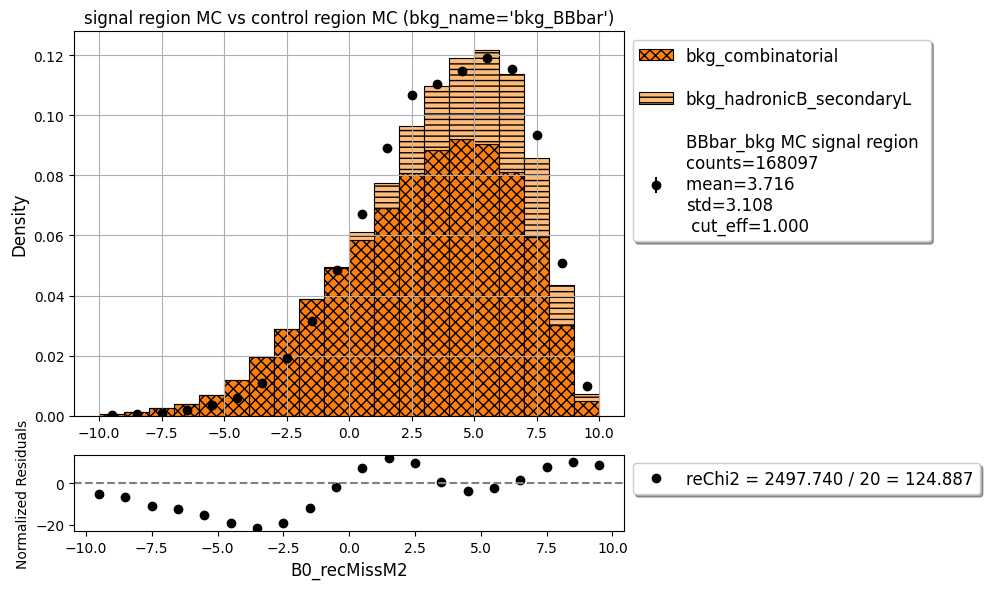

In [49]:
# compare control vs signal regions MC
b1 = np.linspace(-10,10,21)
weights = {'all_mc': 1,
         'bkg_combinatorial': 1,
          'bkg_hadronicB_secondaryL':1}
mpl_comb.plot_mc_sig_control(variable='B0_recMissM2',bins=b1,bkg_name='bkg_BBbar',cut=None,weights=weights,mask=[],
                             density=True, samples_sig=samples_loose, figsize=(10,6),legend_nc=1,text_fs=12,
                             apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight',)

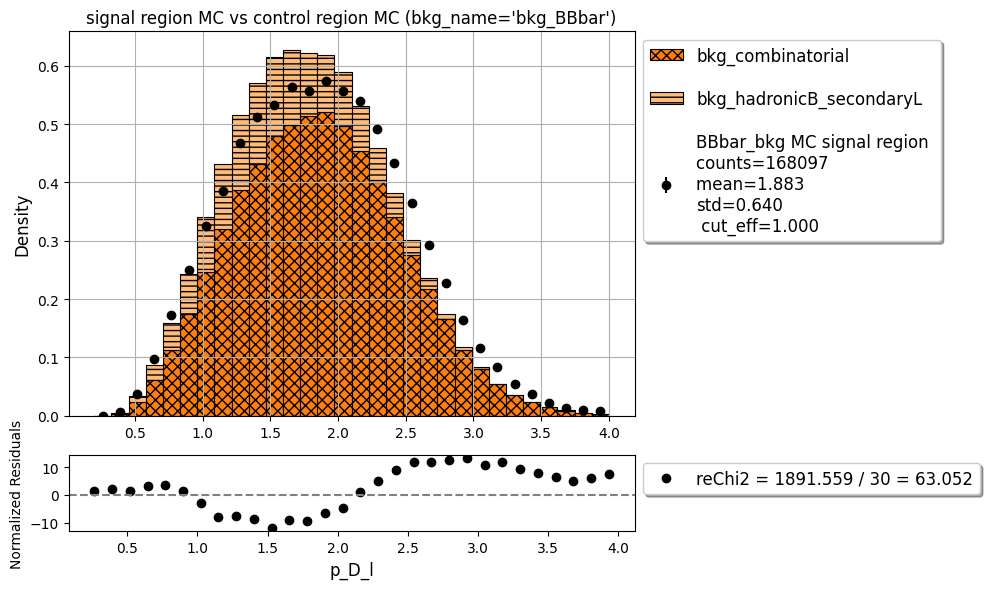

In [50]:
# compare control vs signal regions MC
b1 = np.linspace(0.2,4,31)
weights = {'all_mc': 1,
         'bkg_combinatorial': 1,
          'bkg_hadronicB_secondaryL':1}
mpl_comb.plot_mc_sig_control(variable='p_D_l',bins=b1,bkg_name='bkg_BBbar',cut=None,weights=weights,mask=[],
                             density=True, samples_sig=samples_loose, figsize=(10,6),legend_nc=1,text_fs=12,
                             apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight',)

cut= 1.855<D_M<1.885


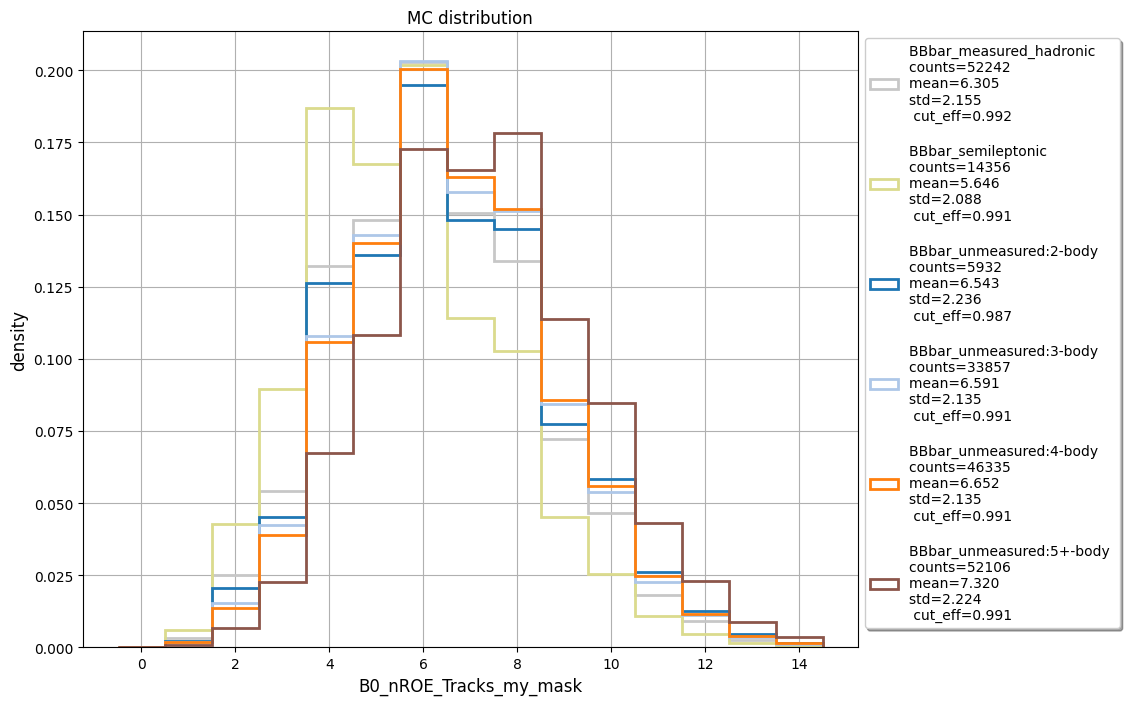

In [62]:
b1 = np.linspace(-0.5,14.5,16)
comb_conpon = ['BBbar_measured_hadronic', 'BBbar_semileptonic', 'BBbar_unmeasured:2-body', 'BBbar_unmeasured:3-body',
         'BBbar_unmeasured:4-body', 'BBbar_unmeasured:5+-body', ]
mpl_comb_sub.plot_mc_1d_overlaid(variable='B0_nROE_Tracks_my_mask',bins=b1,mask=[],cut='1.855<D_M<1.885',errorbars=False,
                        show_only=comb_conpon,density=True,figsize=(10,8) ,legend_nc=1, text_fs=12)

cut= 1.855<D_M<1.885


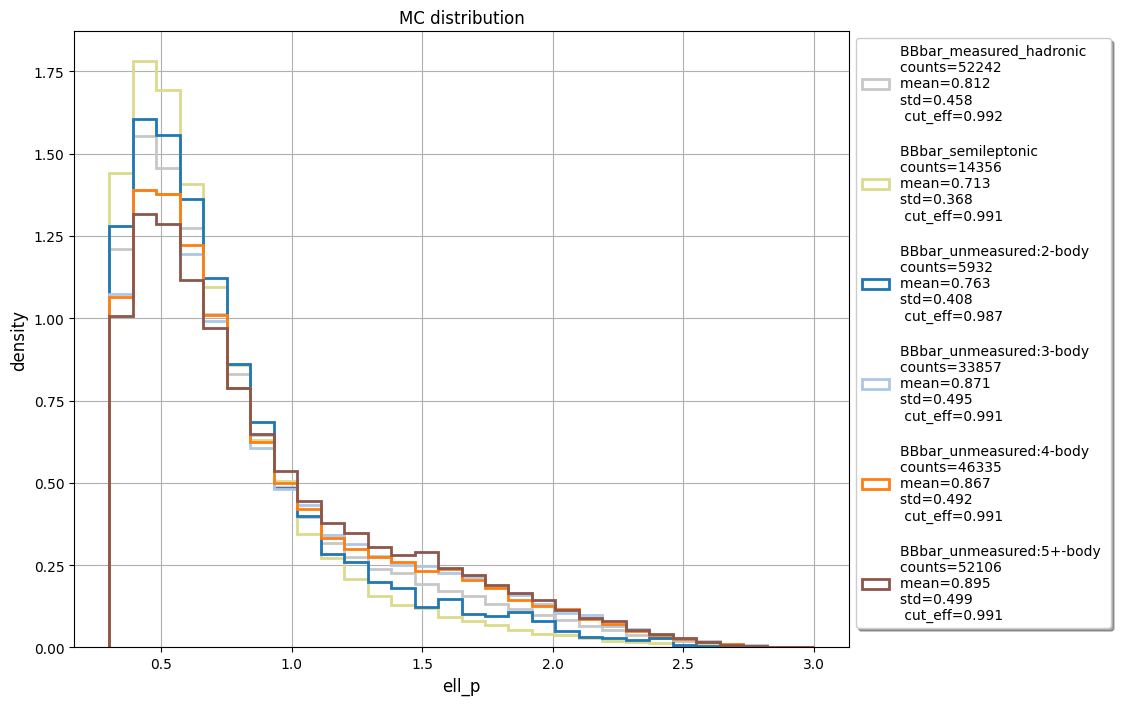

In [63]:
b1 = np.linspace(0.3,3,31)
mpl_comb_sub.plot_mc_1d_overlaid(variable='ell_p',bins=b1,mask=[],cut='1.855<D_M<1.885',errorbars=False,
                        show_only=comb_conpon,density=True,figsize=(10,8) ,legend_nc=1, text_fs=12)

cut= 1.855<D_M<1.885


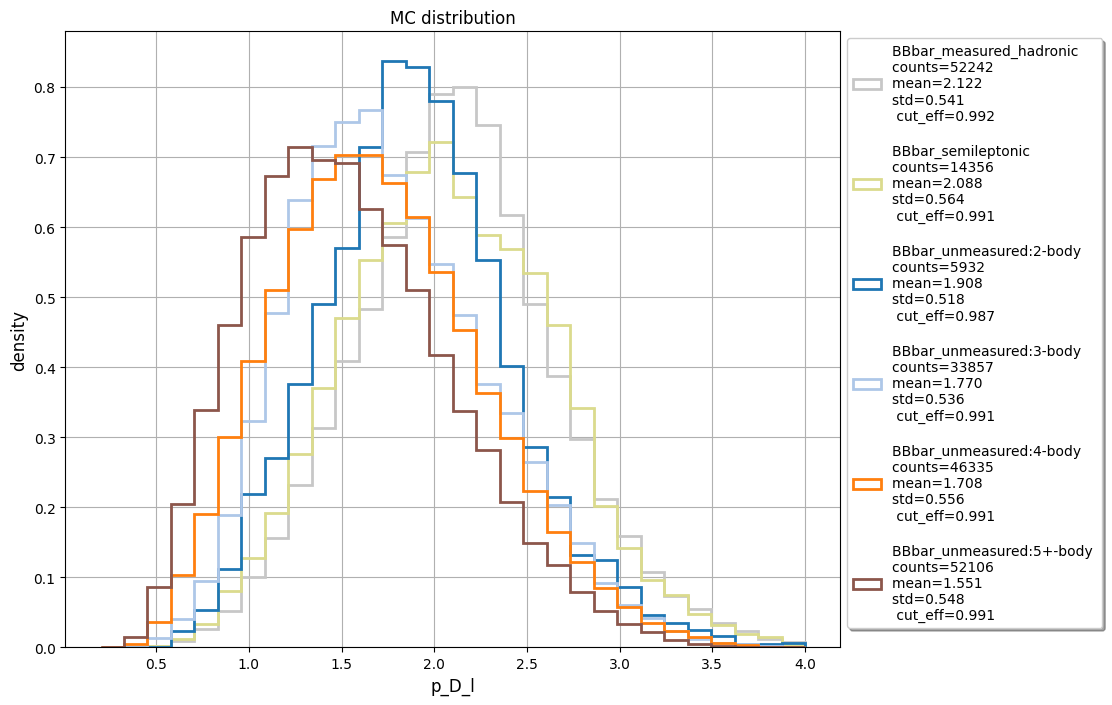

In [64]:
b1 = np.linspace(0.2,4,31)
mpl_comb_sub.plot_mc_1d_overlaid(variable='p_D_l',bins=b1,mask=[],cut='1.855<D_M<1.885',errorbars=False,
                        show_only=comb_conpon,density=True,figsize=(10,8) ,legend_nc=1, text_fs=12)

cut= 1.855<D_M<1.885


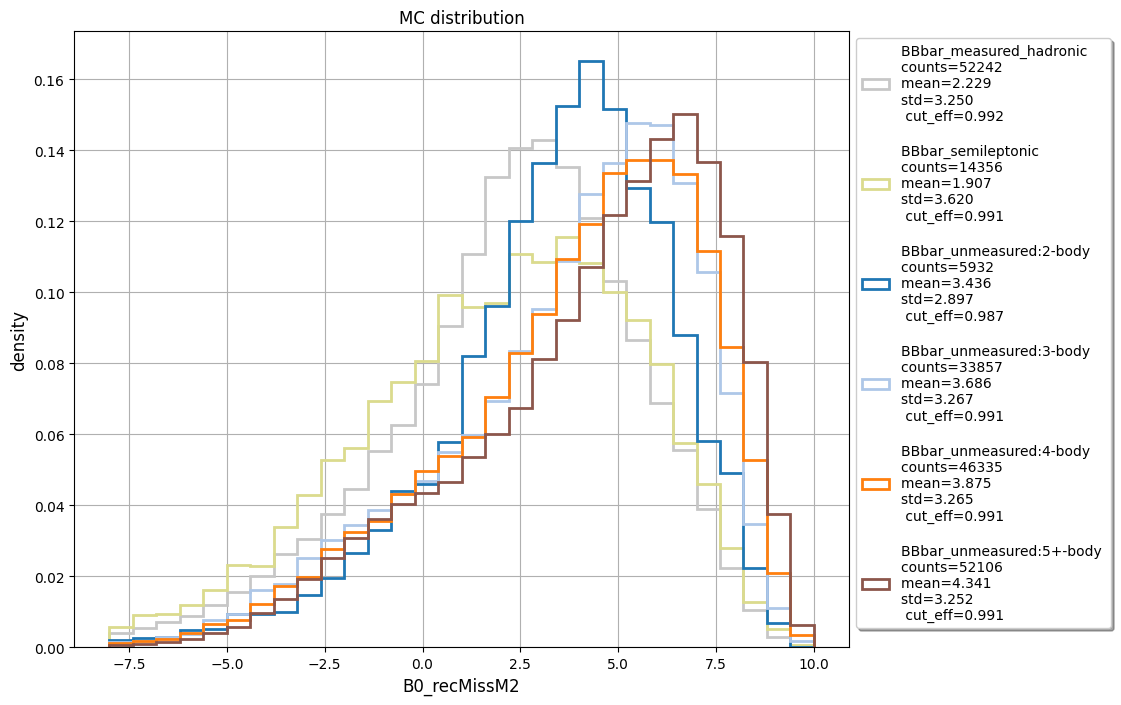

In [68]:
b1 = np.linspace(-8,10,31)
mpl_comb_sub.plot_mc_1d_overlaid(variable='B0_recMissM2',bins=b1,mask=[],cut='1.855<D_M<1.885',errorbars=False,
                        show_only=comb_conpon,density=True,figsize=(10,8) ,legend_nc=1, text_fs=12)

# Control regions
## 1. BDT comb region and B0_vtxReChi2>3
### a. Plot data vs MC

cut= 1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1


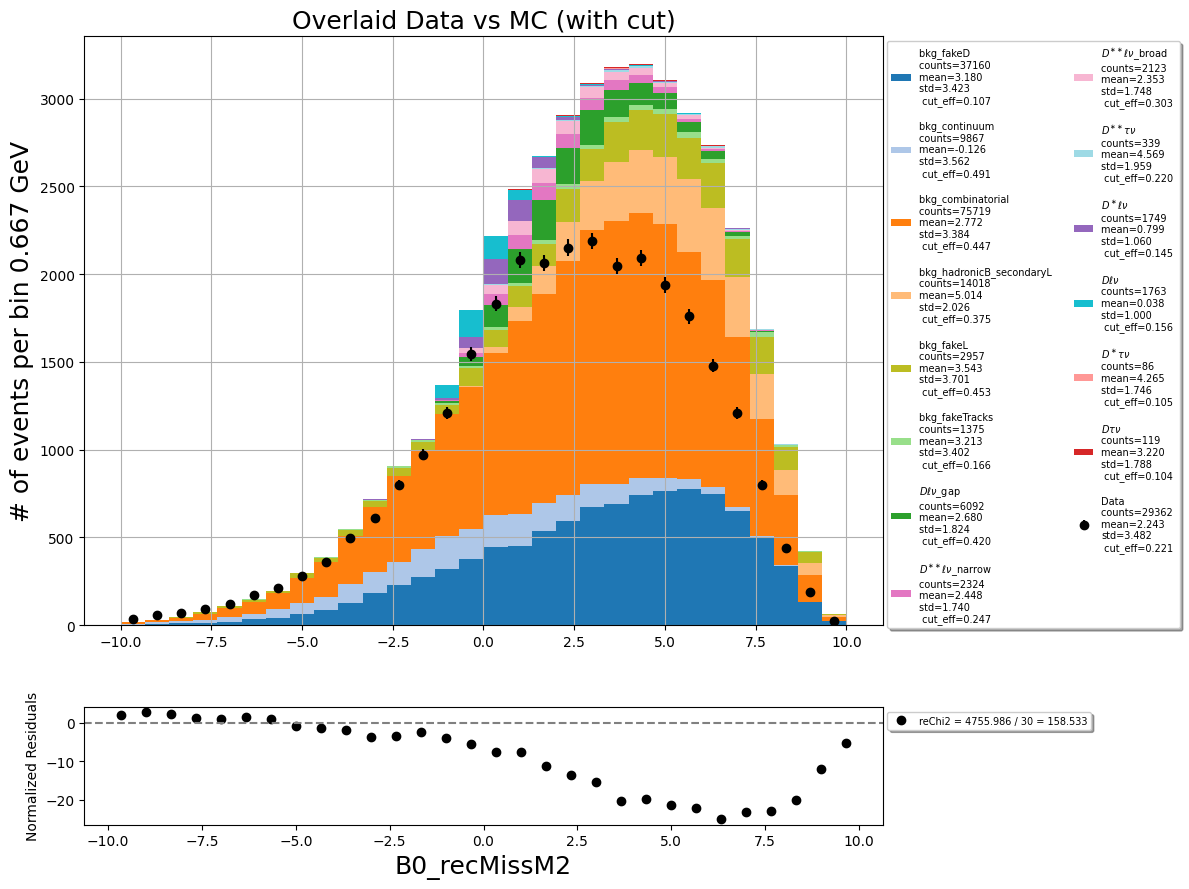

In [5]:
b1 = np.linspace(-10,10,31)
weights={'all_mc':0.25 * 1.038,}
data_hist_all, mc_hist_all = mpl_comb.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1',mask=[],
    figsize=(12,9),legend_nc=2,legend_fs=7,text_fs=18, weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight') # 'total_PIDweight'

cut= (D_M<1.855 or 1.885<D_M) and fakeD_prob<0.1 and sig_prob<0.1


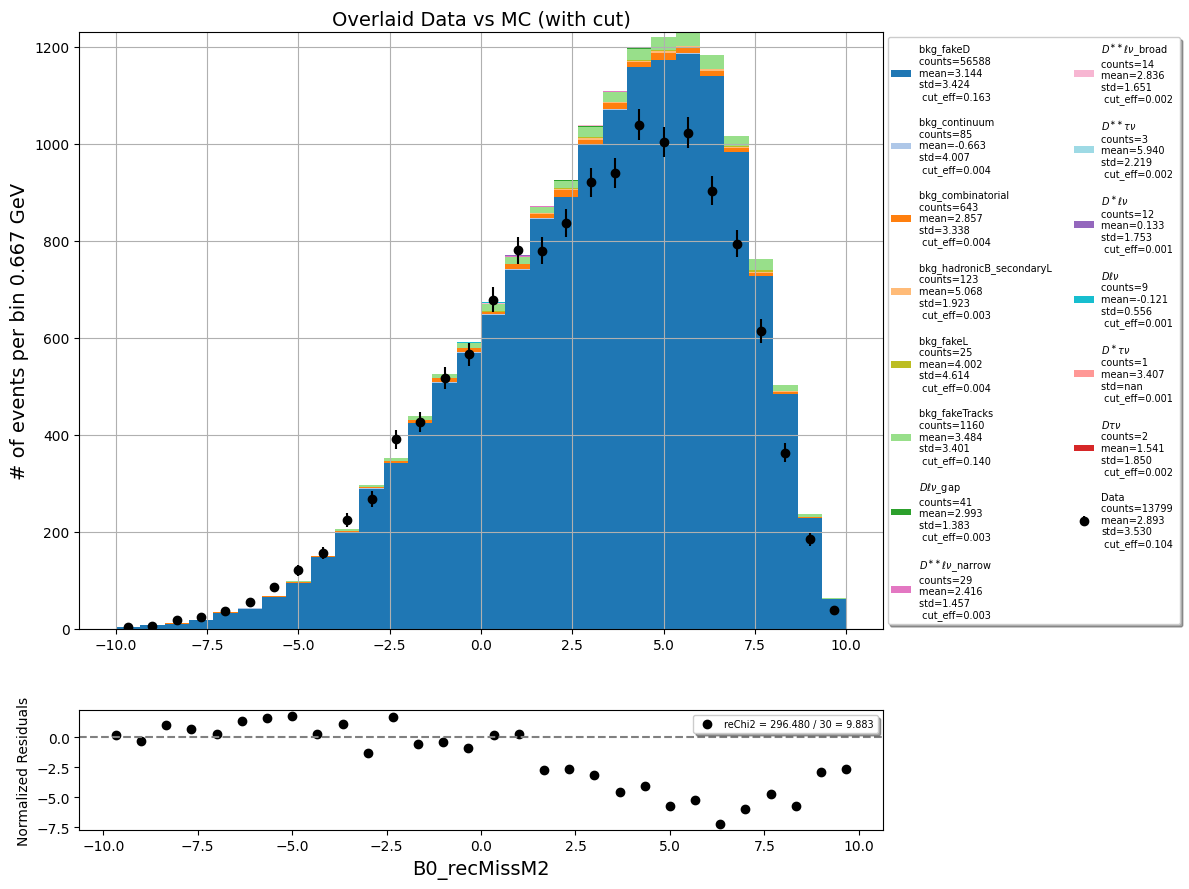

In [8]:
b1 = np.linspace(-10,10,31)
weights={'all_mc':0.25 * 1.038,}
data_hist_all, mc_hist_all = mpl_comb.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut='(D_M<1.855 or 1.885<D_M) and fakeD_prob<0.1 and sig_prob<0.1',mask=[],
    figsize=(12,9),legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

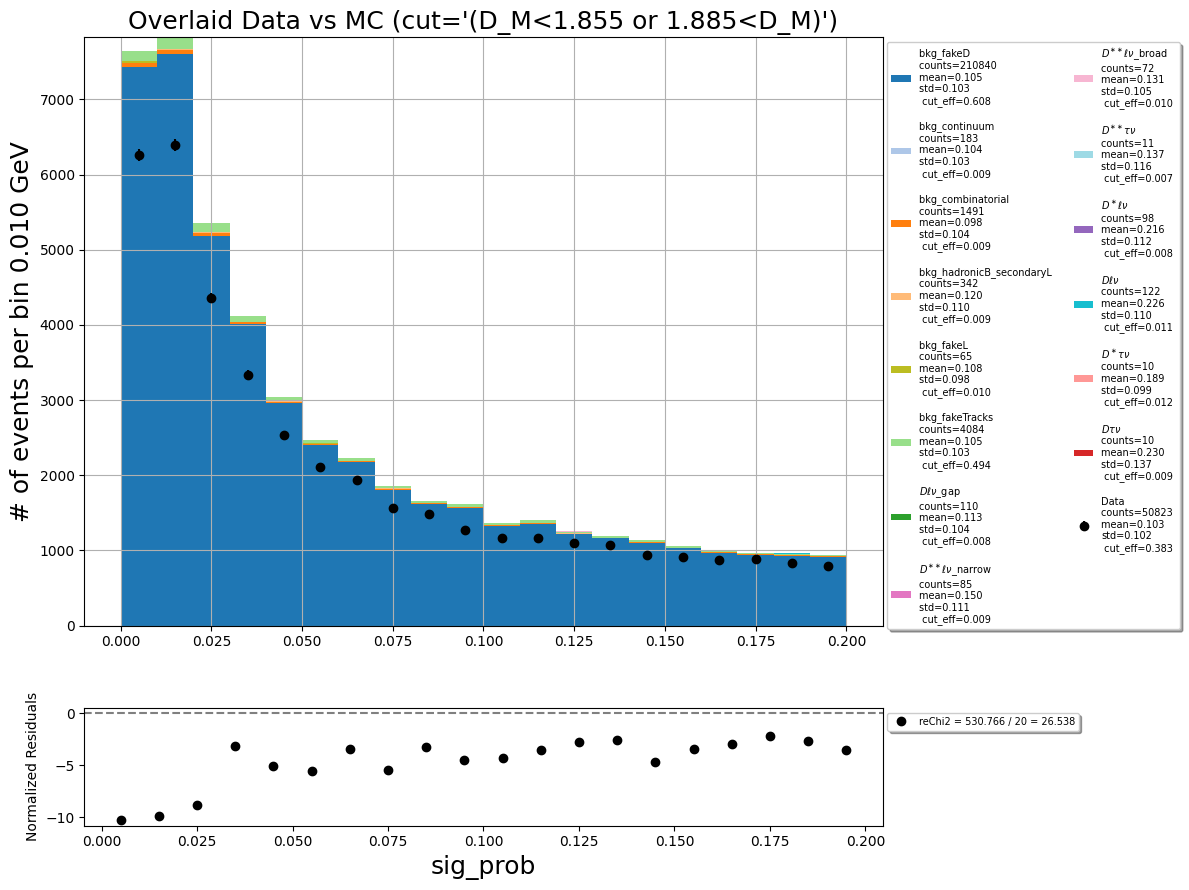

In [128]:
b1 = np.linspace(0,0.2,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_comb.plot_data_mc_stacked(
    variable='sig_prob',bins=b1,cut='(D_M<1.855 or 1.885<D_M)',mask=[],
    figsize=(12,9),legend_nc=2,legend_fs=7,weights=weights, text_fs=18,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight') # 'total_PID_weigh'

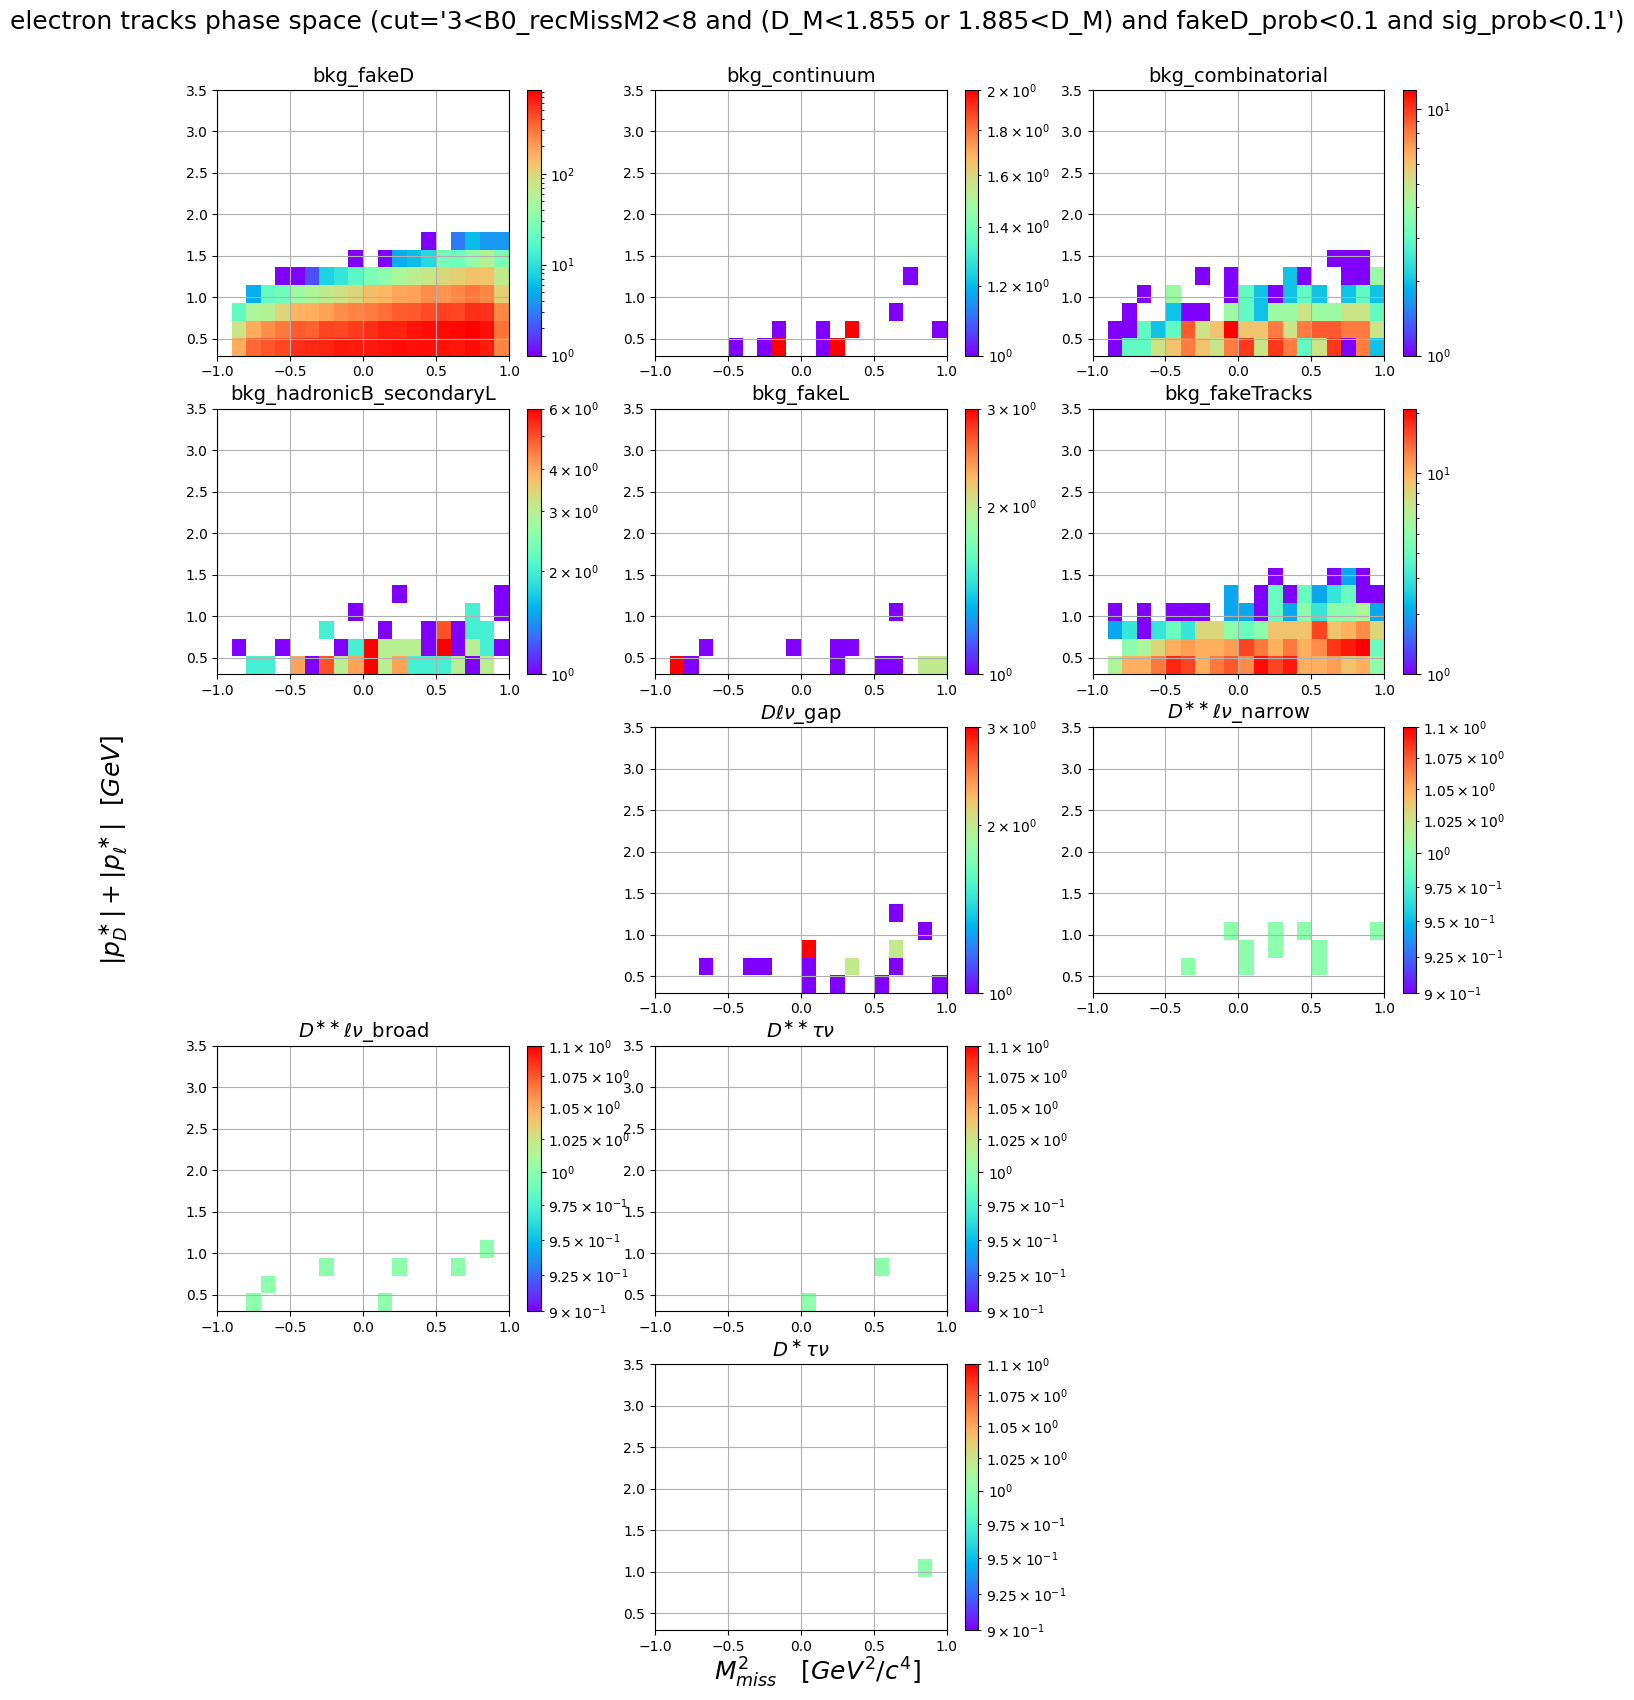

In [150]:
bx = np.linspace(-1,1,21)
by = np.linspace(0.3, 3.5, 16)

# data_hist_all, mc_hist_all = mpl_comb.plot_data_mc_stacked(
#     variable='B0_recMissM2',bins=b1,cut='(D_M<1.855 or 1.885<D_M) and fakeD_prob<0.1 and sig_prob<0.1',mask=[],
#     figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
#     apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

mpl_comb.plot_all_2Dhist(bin_list=[bx, by], var_list=['ell_BFbrems_cosTheta','ell_BFbrems_p'],title='electron tracks phase space',
                         cut='3<B0_recMissM2<8 and (D_M<1.855 or 1.885<D_M) and fakeD_prob<0.1 and sig_prob<0.1',mask=None)

In [152]:
samples_comb['bkg_fakeD'].query('3<B0_recMissM2<8').ell_mcPDG.value_counts()

ell_mcPDG
 11.0      87466
-11.0      86153
 211.0      2539
-211.0      2311
 321.0       206
-321.0       201
-13.0         43
 13.0         33
-2212.0        8
 2212.0        4
Name: count, dtype: int64

cut= 1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1


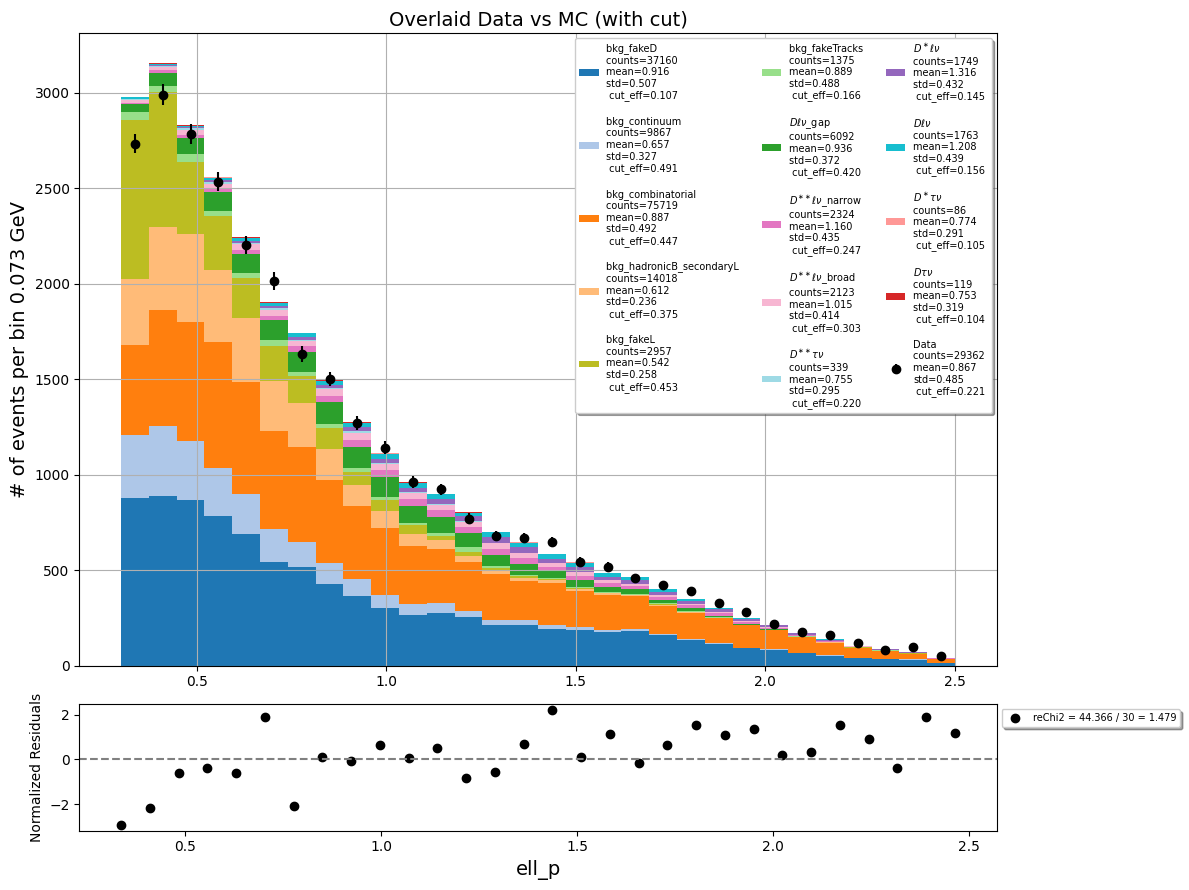

In [6]:
b1 = np.linspace(0.3,2.5,31)
weights={'all_mc':0.25,
         'bkg_fakeD': 0.25 * 0.87,
         'bkg_continuum': 0.25 * 1,
         'BBbar_measured_hadronic':0.25 * 1,
         'BBbar_semileptonic': 0.25 * 1,
         'BBbar_unmeasured:2-body':0.25 * 1,
         'BBbar_unmeasured:3-body':0.25 * 1,
         'BBbar_unmeasured:4-body':0.25 * 1,
         'BBbar_unmeasured:5+-body':0.25 * 1,}
data_hist_all, mc_hist_all = mpl_comb_sub.plot_data_mc_stacked(
    variable='ell_p',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1',mask=[],
    figsize=(12,9),legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

cut= 1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1


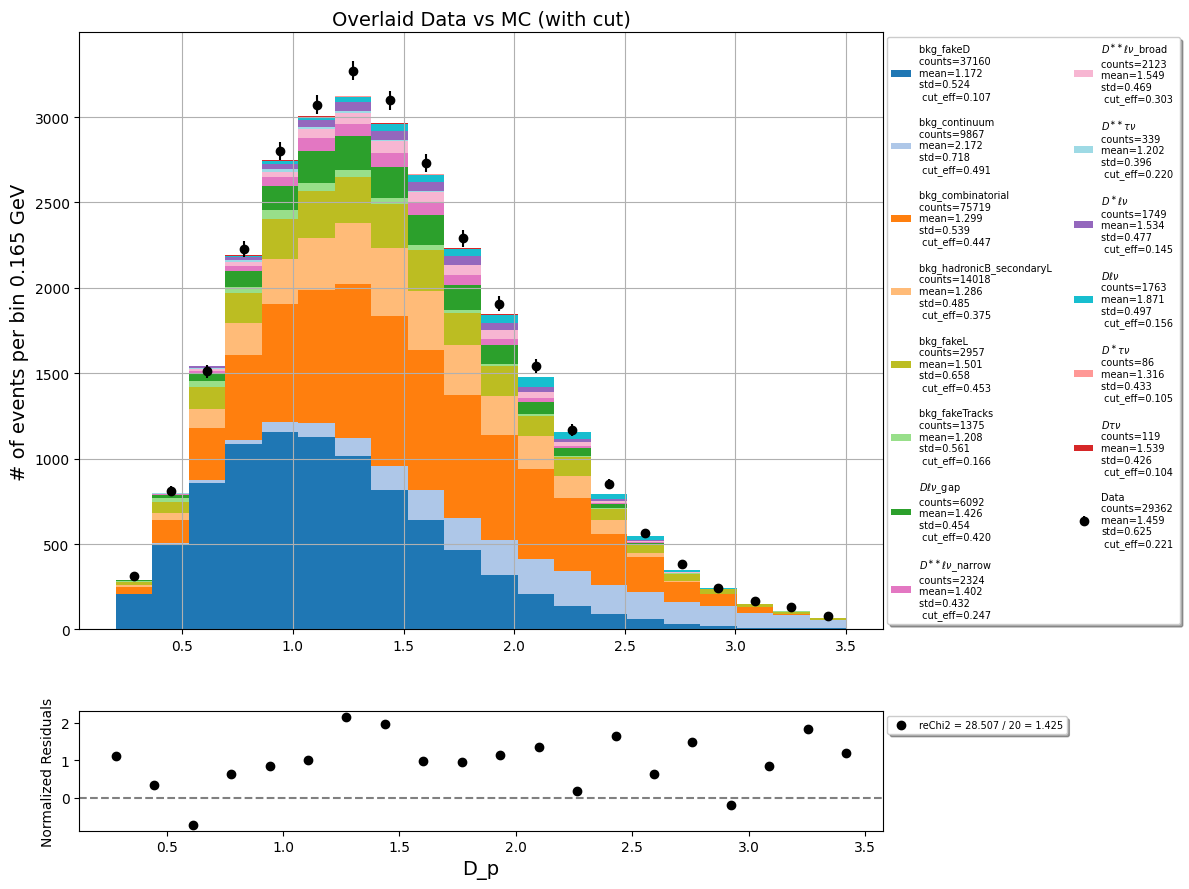

In [6]:
b1 = np.linspace(0.2,3.5,21)
weights={'all_mc':0.25,
         'bkg_fakeD': 0.25 * 0.87,
         'bkg_continuum': 0.25 * 1,
         'BBbar_measured_hadronic':0.25 * 1,
         'BBbar_semileptonic': 0.25 * 1,
         'BBbar_unmeasured:2-body':0.25 * 1,
         'BBbar_unmeasured:3-body':0.25 * 1,
         'BBbar_unmeasured:4-body':0.25 * 1,
         'BBbar_unmeasured:5+-body':0.25 * 1,}
data_hist_all, mc_hist_all = mpl_comb_sub.plot_data_mc_stacked(
    variable='D_p',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1',mask=[],
    figsize=(12,9),legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

cut= 1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1


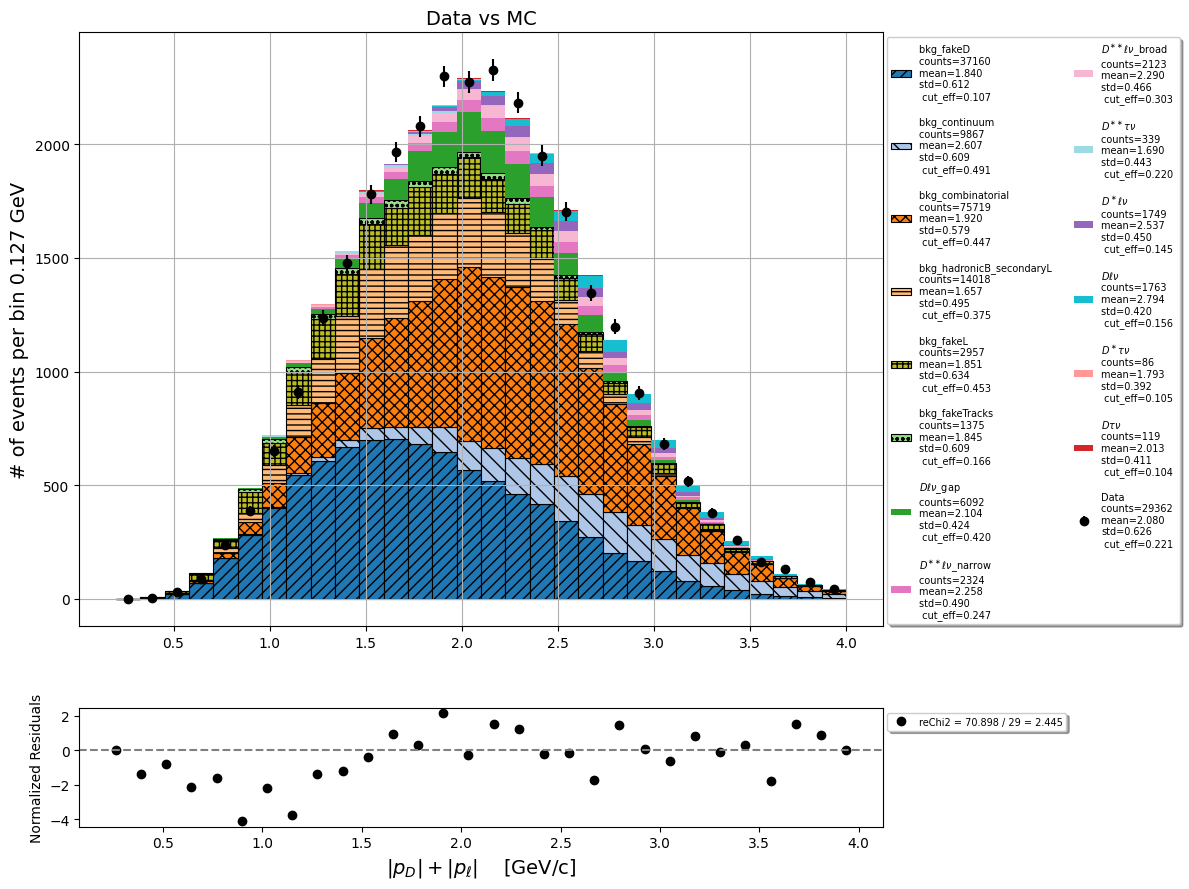

In [13]:
b1 = np.linspace(0.2,4,31)
weights={'all_mc':0.25,
         'bkg_fakeD': 0.25 * 0.87,
         'bkg_continuum': 0.25 * 1,
         'BBbar_measured_hadronic':0.25 * 1,
         'BBbar_semileptonic': 0.25 * 1,
         'BBbar_unmeasured:2-body':0.25 * 1,
         'BBbar_unmeasured:3-body':0.25 * 1,
         'BBbar_unmeasured:4-body':0.25 * 1,
         'BBbar_unmeasured:5+-body':0.25 * 1,}

data_hist_all, mc_hist_all = mpl_comb_sub.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1',mask=[],
    figsize=(12,9),legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

cut= 1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1


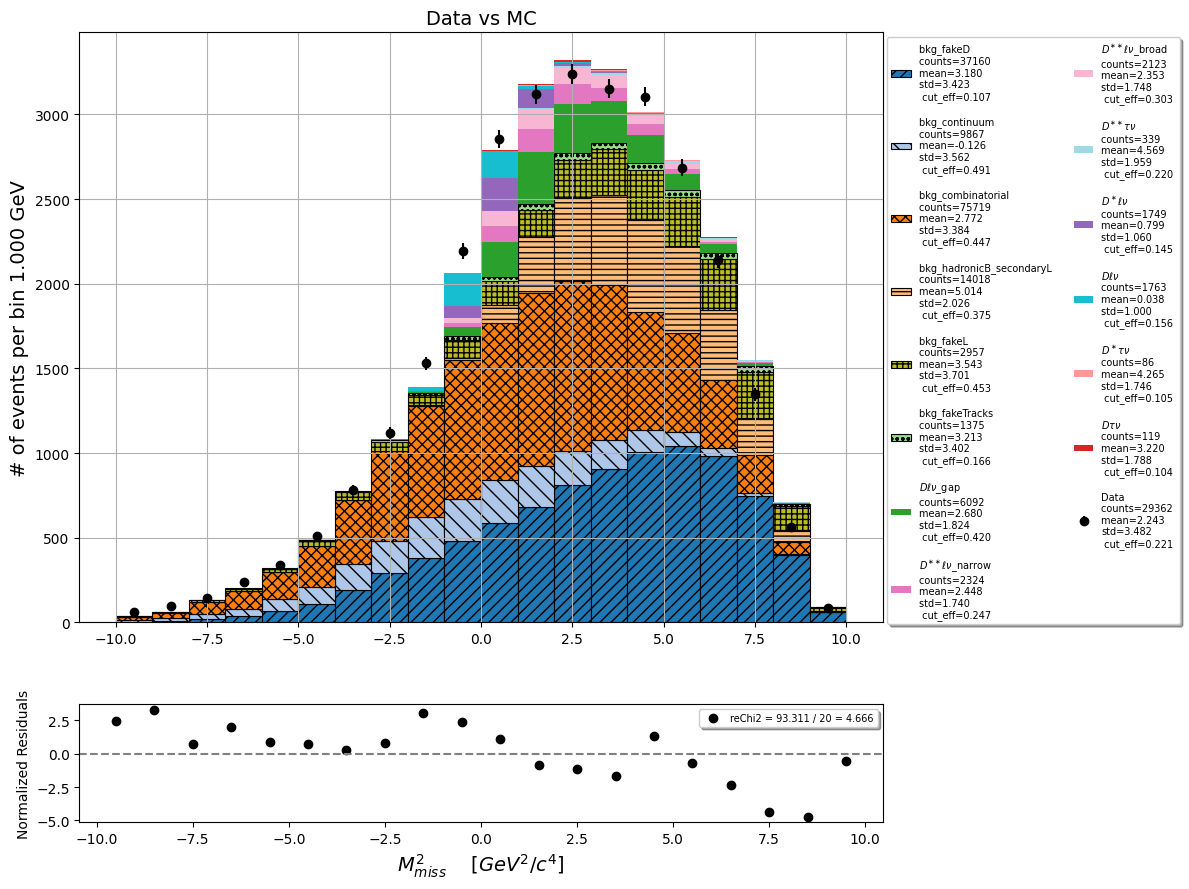

In [16]:
b1 = np.linspace(-10,10,21)
weights={'all_mc':0.25,
         'bkg_fakeD': 0.25 * 0.87,
         'bkg_continuum': 0.25 * 1,
         'BBbar_measured_hadronic':0.25 * 1,
         'BBbar_semileptonic': 0.25 * 1,
         'BBbar_unmeasured:2-body':0.25 * 1,
         'BBbar_unmeasured:3-body':0.25 * 1,
         'BBbar_unmeasured:4-body':0.25 * 1,
         'BBbar_unmeasured:5+-body':0.25 * 1,}

data_hist_all, mc_hist_all = mpl_comb_sub.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1',mask=[],
    figsize=(12,9),legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight')

In [ ]:
b1 = np.linspace(-10,10,21)
weights={'all_mc':0.25,
         'bkg_fakeD': 0.25 * 0.86,
         'bkg_continuum': 0.25 * 1,
         'BBbar_measured_hadronic':0.25 * 1,
         'BBbar_semileptonic': 0.25 * 1,
         'BBbar_unmeasured:2-body':0.25 * 1,
         'BBbar_unmeasured:3-body':0.25 * 1,
         'BBbar_unmeasured:4-body':0.25 * 1,
         'BBbar_unmeasured:5+-body':0.25 * 1,}

data_hist_all, mc_hist_all = mpl_comb_sub.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1',mask=[],
    figsize=(12,9),legend_nc=3,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight')

In [ ]:
b1 = np.linspace(0.2,4,31)
weights={'all_mc':0.25,
         'bkg_fakeD': 0.25 * 0.86,
         'bkg_continuum': 0.25 * 1.3,
         'BBbar_measured_hadronic':0.25 * 1.56,
         'BBbar_semileptonic': 0.25 * 1,
         'BBbar_unmeasured:2-body':0.25 * 0.01,
         'BBbar_unmeasured:3-body':0.25 * 0.48,
         'BBbar_unmeasured:4-body':0.25 * 0.34,
         'BBbar_unmeasured:5+-body':0.25 * 0,}

data_hist_all, mc_hist_all = mpl_comb_sub.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1',mask=[],
    figsize=(12,9),legend_nc=3,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

In [ ]:
b1 = np.linspace(0.2,3.5,21)
weights={'all_mc':0.25,
         'bkg_fakeD': 0.25 * 0.86,
         'BBbar_measured_hadronic':0.25 * 1,
         'BBbar_semileptonic': 0.25 * 1,
         'BBbar_unmeasured:2-body':0.25 * 0.7,
         'BBbar_unmeasured:3-body':0.25 * 0.78,
         'BBbar_unmeasured:4-body':0.25 * 0.47,
         'BBbar_unmeasured:5-body':0.25 * 0,
         'BBbar_unmeasured:6-body':0.25 * 0,
         'BBbar_unmeasured:7-body':0.25 * 0,}
data_hist_all, mc_hist_all = mpl_comb_sub.plot_data_mc_stacked(
    variable='D_p',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1',
    mask=[],figsize=(12,9),legend_nc=3,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

### b. Plot ROE variables

cut= 1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1


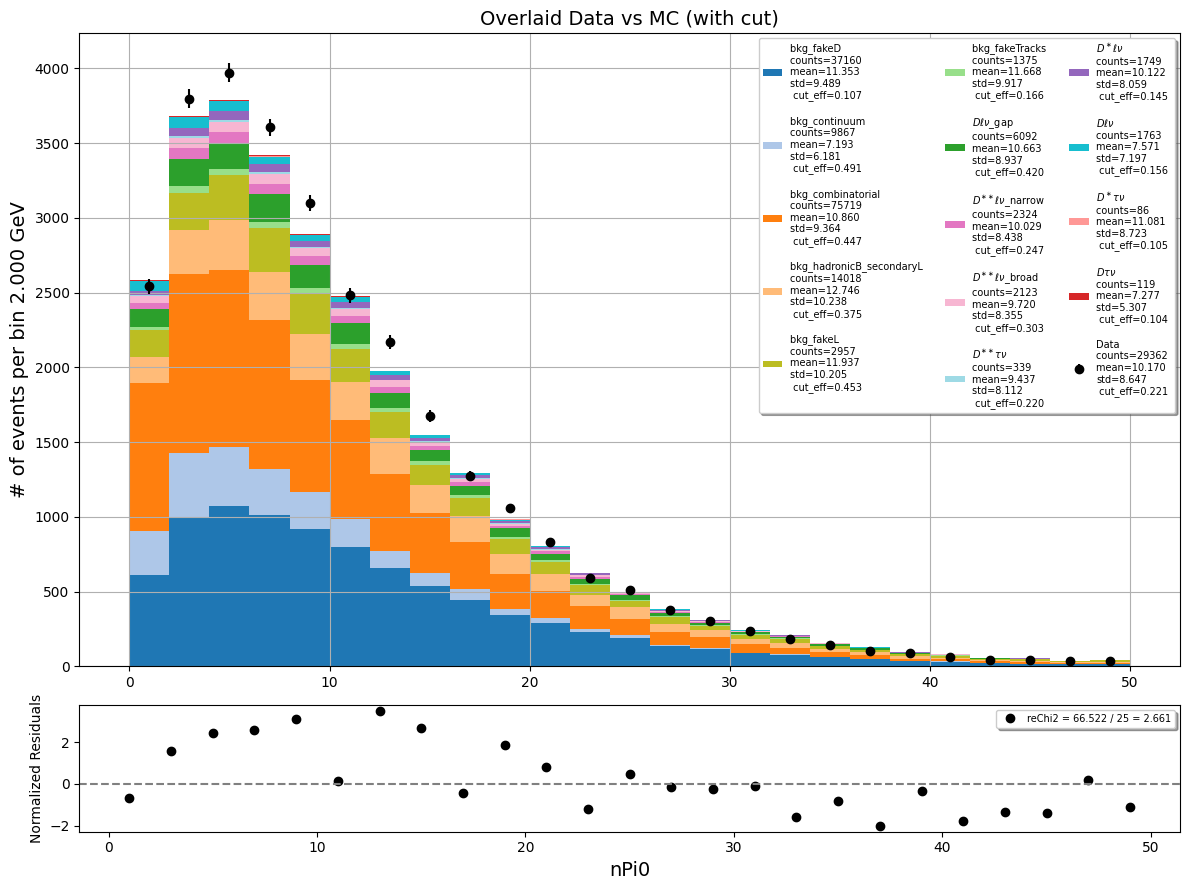

In [21]:
b1 = np.linspace(0,50,26)
weights={'all_mc':0.25,
         'bkg_fakeD': 0.25 * 0.87,
         'BBbar_measured_hadronic':0.25 * 1,
         'BBbar_semileptonic': 0.25 * 1,
         'BBbar_unmeasured:2-body':0.25 * 1,
         'BBbar_unmeasured:3-body':0.25 * 1,
         'BBbar_unmeasured:4-body':0.25 * 1,
         'BBbar_unmeasured:5+-body':0.25 * 1,}
data_hist_all, mc_hist_all = mpl_comb_sub.plot_data_mc_stacked(
    variable='nPi0',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1',
    mask=[],figsize=(12,9),legend_nc=3,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

cut= 1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1


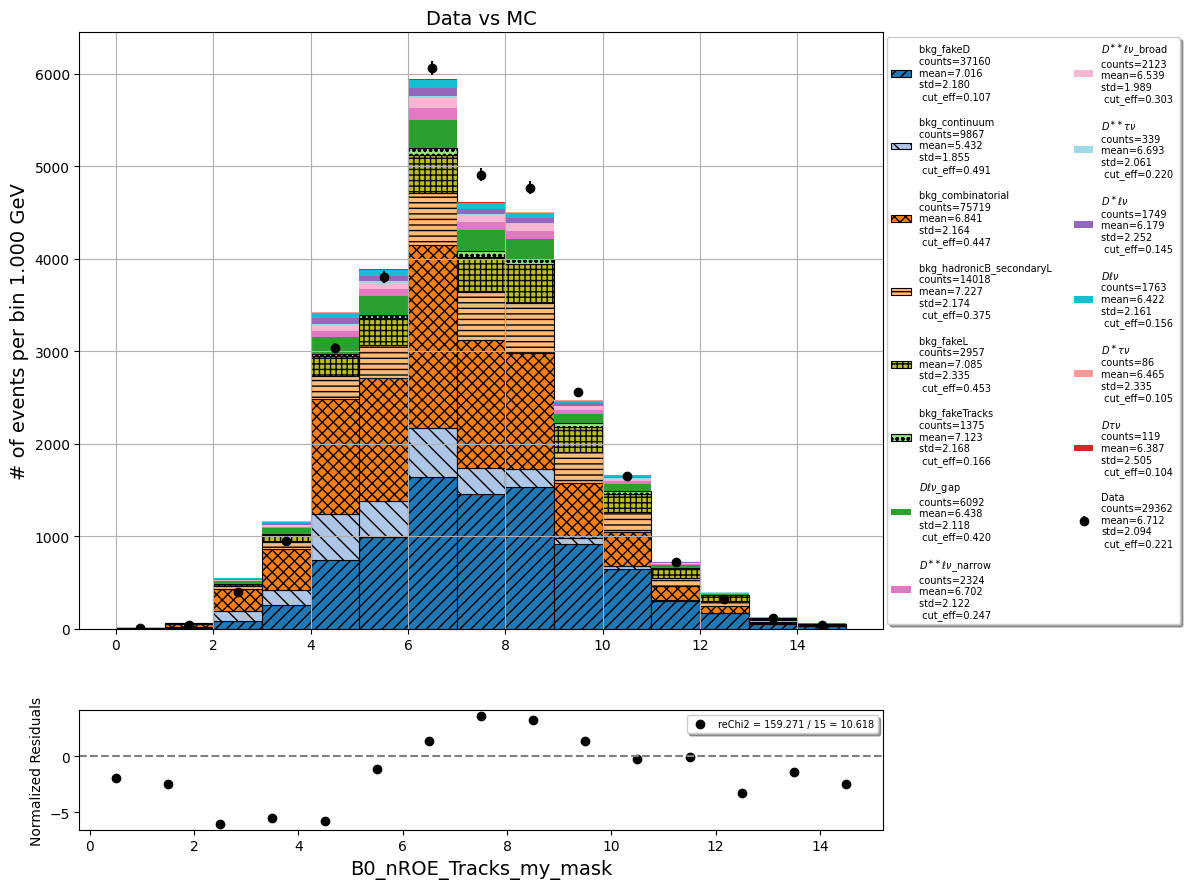

In [18]:
b1 = np.linspace(0,15,16)
weights={'all_mc':0.25,
         'bkg_fakeD': 0.25 * 0.87,
         'BBbar_measured_hadronic':0.25 * 1,
         'BBbar_semileptonic': 0.25 * 1,
         'BBbar_unmeasured:2-body':0.25 * 1,
         'BBbar_unmeasured:3-body':0.25 * 1,
         'BBbar_unmeasured:4-body':0.25 * 1,
         'BBbar_unmeasured:5+-body':0.25 * 1,}
data_hist_all, mc_hist_all = mpl_comb_sub.plot_data_mc_stacked(
    variable='B0_nROE_Tracks_my_mask',bins=b1,cut='1.855<D_M<1.885 and fakeD_prob<0.1 and sig_prob<0.1',
    mask=[],figsize=(12,9),legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PIDweight'

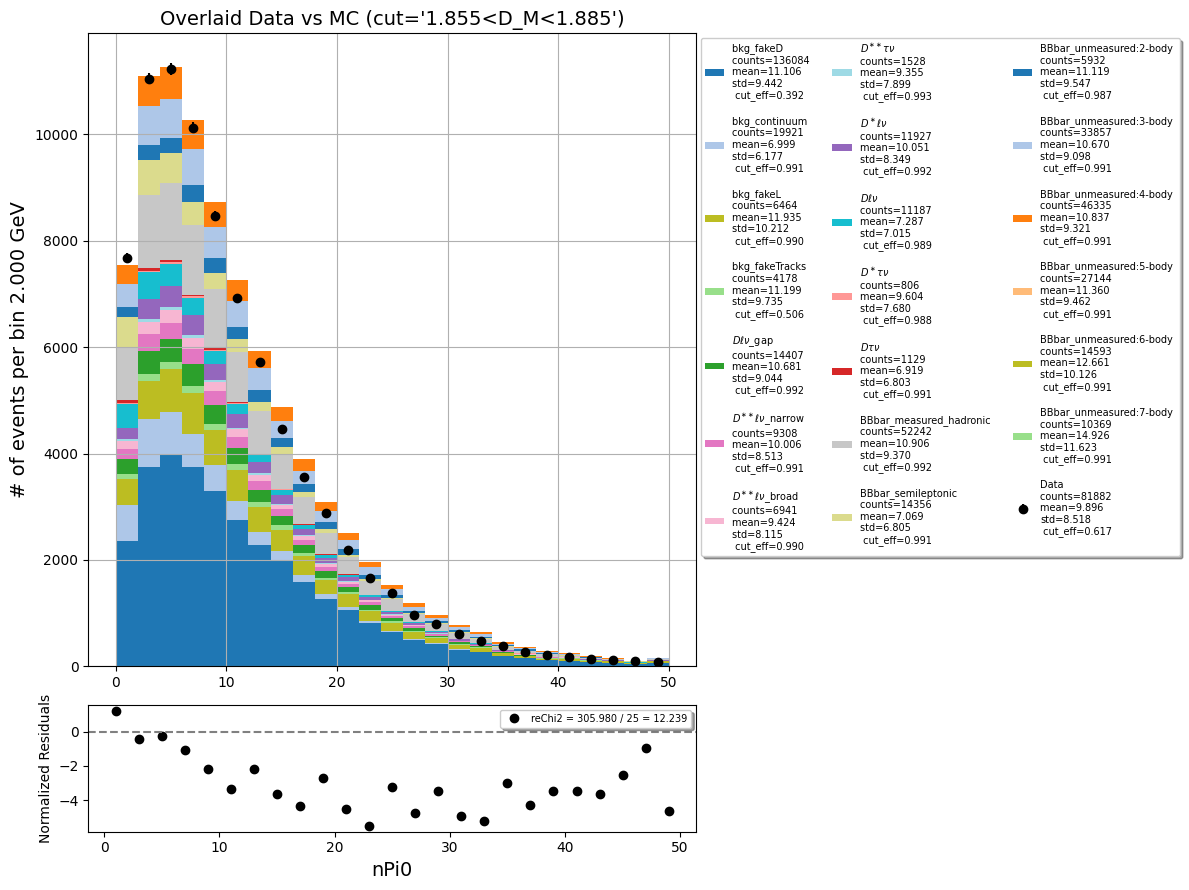

In [19]:
b1 = np.linspace(0,50,26)
weights={'all_mc':0.25,
         'bkg_fakeD': 0.25 * 0.845,
         'BBbar_measured_hadronic':0.25 * 1,
         'BBbar_semileptonic': 0.25 * 1,
         'BBbar_unmeasured:2-body':0.25 * 0.7,
         'BBbar_unmeasured:3-body':0.25 * 0.78,
         'BBbar_unmeasured:4-body':0.25 * 0.47,
         'BBbar_unmeasured:5-body':0.25 * 0,
         'BBbar_unmeasured:6-body':0.25 * 0,
         'BBbar_unmeasured:7-body':0.25 * 0,}
data_hist_all, mc_hist_all = mpl_comb_sub.plot_data_mc_stacked(
    variable='nPi0',bins=b1,cut='1.855<D_M<1.885',mask=[],
    figsize=(12,9),legend_nc=3,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

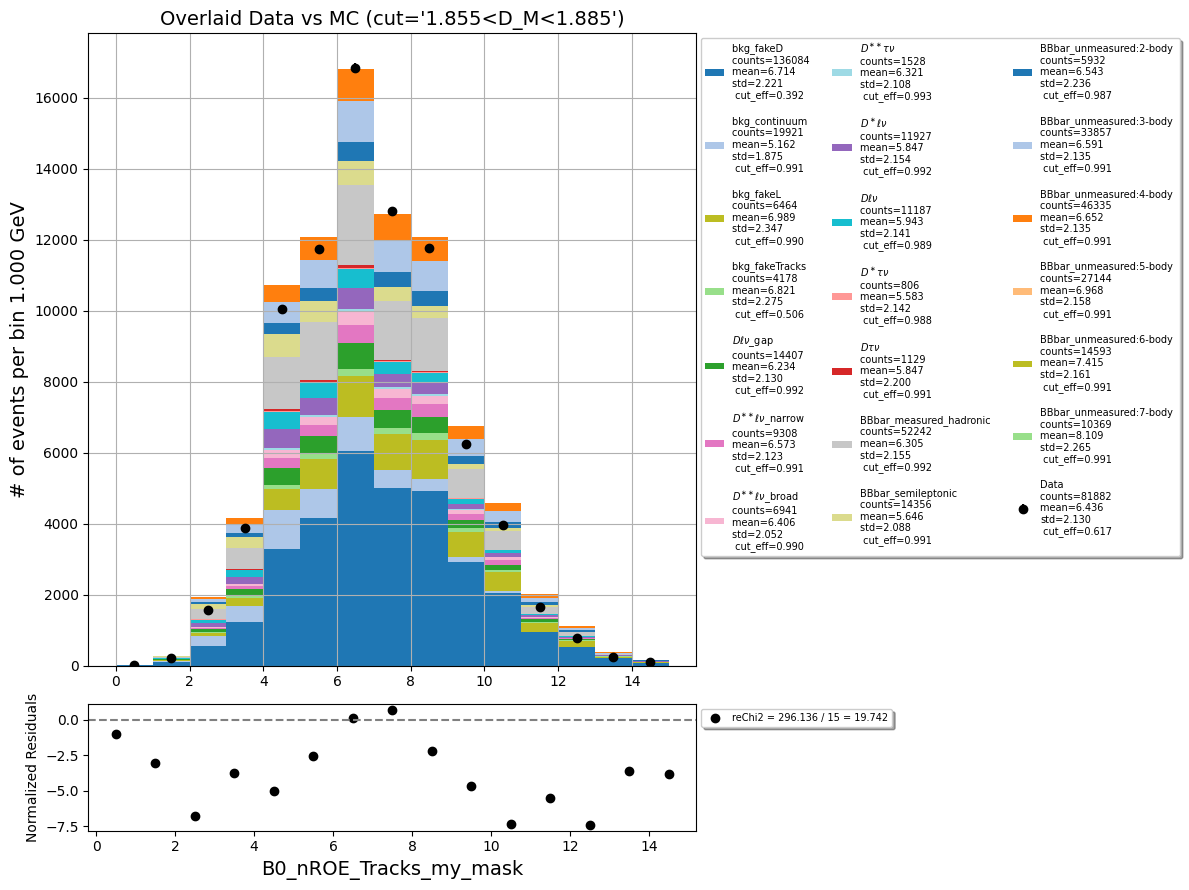

In [20]:
b1 = np.linspace(0,15,16)
weights={'all_mc':0.25,
         'bkg_fakeD': 0.25 * 0.845,
         'BBbar_measured_hadronic':0.25 * 1,
         'BBbar_semileptonic': 0.25 * 1,
         'BBbar_unmeasured:2-body':0.25 * 0.7,
         'BBbar_unmeasured:3-body':0.25 * 0.78,
         'BBbar_unmeasured:4-body':0.25 * 0.47,
         'BBbar_unmeasured:5-body':0.25 * 0,
         'BBbar_unmeasured:6-body':0.25 * 0,
         'BBbar_unmeasured:7-body':0.25 * 0,}
data_hist_all, mc_hist_all = mpl_comb_sub.plot_data_mc_stacked(
    variable='B0_nROE_Tracks_my_mask',bins=b1,cut='1.855<D_M<1.885',mask=[],
    figsize=(12,9),legend_nc=3,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight') # 'total_PID_weigh'

### c. Subtract the fakeD

cut= fakeD_prob<0.1 and sig_prob<0.1


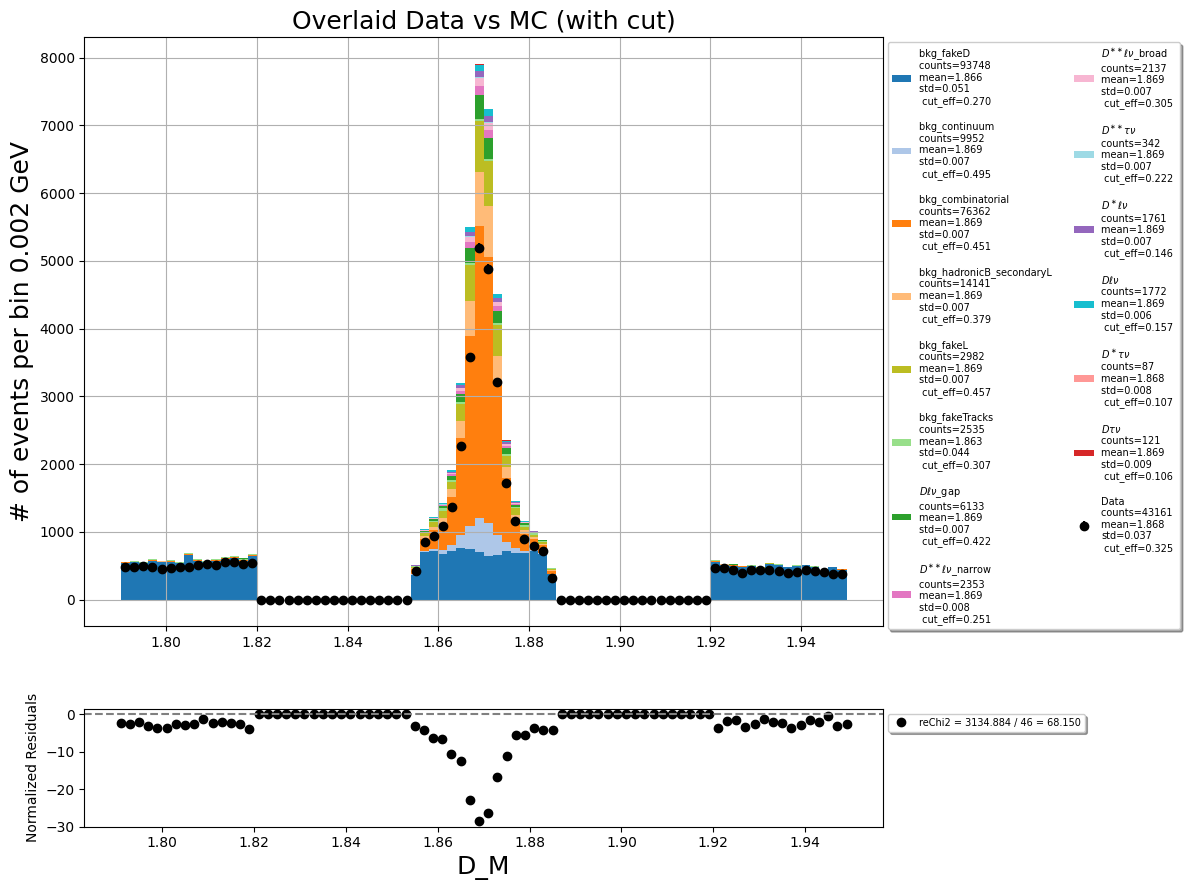

In [120]:
# showing the fake D and sidebands in D_M
b1 = np.linspace(1.79,1.95,81)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_comb.plot_data_mc_stacked(
    variable='D_M',bins=b1,cut='fakeD_prob<0.1 and sig_prob<0.1',mask=[],
    figsize=(12,9),legend_nc=2,legend_fs=7,text_fs=18, weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight') # 'total_PID_weigh'

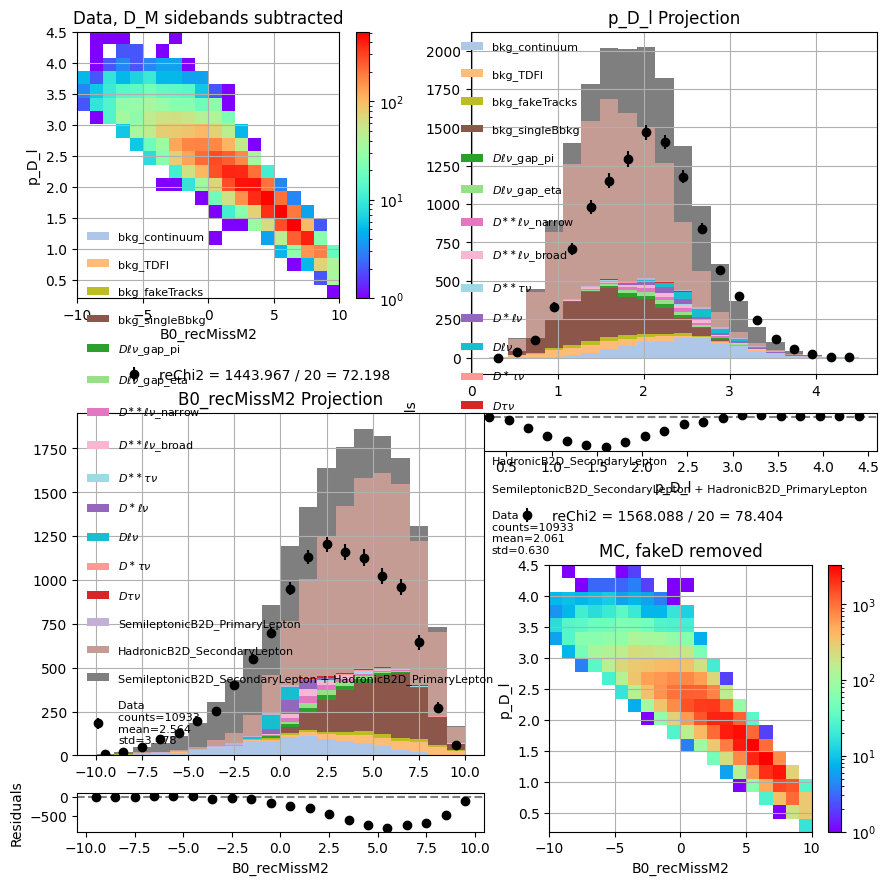

In [18]:
# e channel, lgb_comb
b_mm2 = np.linspace(-10,10,21)
b_pDl = np.linspace(0.2,4.5,21)
scale = {'data left sideband': 5580/5943/2,
         'data right sideband': 5580/5218/2,
         'data signal region': 1,
         'all_mc': 0.25}

par_dict={'var_list':['B0_recMissM2','p_D_l'],
          'bin_list': [b_mm2, b_pDl],
          'cut': 'B0_vtxReChi2>3', #'B0_roeMbc_my_mask>5.1 and -4<B0_roeDeltae_my_mask<1',
          'weights': scale,
          'correction': False,
          'mask': ['bkg_fakeD']}
indices_threshold, temp_data = mpl_comb_subcat.plot_data_subtracted_and_mc(**par_dict)

In [ ]:
# mu channel
b_mm2 = np.linspace(-13,10,21)
b_pDl = np.linspace(0.2,5,21)
scale = {'data left sideband': 2209/2351/2 * 200/187,
         'data right sideband': 2209/2066/2 * 200/187,
         'data signal region': 200/187}

par_dict={'var_list':['B0_CMS3_weMissM2','p_D_l'],
          'bin_list': [b_mm2, b_pDl],
          'cut': 'B0_vtxReChi2>5', #'B0_roeMbc_my_mask>5.1 and -4<B0_roeDeltae_my_mask<1',
          'weights': scale,
          'correction': False,
          'mask': ['bkg_fakeD']}
indices_threshold, temp_data = mpl_comb.plot_data_subtracted_and_mc(**par_dict)

### d.  Fit the combinatorial components

In [8]:
MM2_bins = np.linspace(-10,10,41)
p_D_l_bins = np.linspace(0.3,4,41)
MM2_bins_sb = np.linspace(-10,10,21)
p_D_l_bins_sb = np.linspace(0.2,4,21)
    
temp_data_sr,temp_data_sb,temp_data_sr_merged, temp_data_sb_merged = util.create_templates_new(
    samples=samples_comb_sub,cut='fakeD_prob<0.1 and sig_prob<0.1',variables=['B0_recMissM2','p_D_l'],
    bins_sr=[MM2_bins, p_D_l_bins],bins_sb=[MM2_bins_sb, p_D_l_bins_sb],
     scale_lumi=1, bin_threshold=10,merge_threshold=5,
    use_real_data_instead_of_asimov=True, real_data=df_data_4S_comb,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight',
    sample_to_exclude=['bkg_other_TDTl','bkg_other_signal', 'others',
                      r'$D\ell\nu$_gap',
                       # 'bkg_fakeD', 
                       # 'bkg_continuum',
#                       r'$D^{\ast\ast}\ell\nu$_broad',
#                       r'$D^{\ast\ast}\ell\nu$_narrow',
#                       r'$D\ell\nu$',
#                       r'$D^\ast\ell\nu$',
#                       r'$D\tau\nu$', 
#                       r'$D^\ast\tau\nu$', 
#                       r'$D^{\ast\ast}\tau\nu$',
                      #  'bkg_fakeTracks',
                      # 'bkg_TDFl','bkg_singleBbkg',
                      # 'bkg_combinatorial',
                      ],
    sample_weights={#r'$D\ell\nu$_gap_pi':           0, # 2618 events 
                    r'$D\ell\nu$_gap':          0, # 2404
                    r'$D^{\ast\ast}\ell\nu$_broad': 0.25 * 1.435, # 11540 events from 1/ab
                    r'$D^{\ast\ast}\ell\nu$_narrow':0.25,
                    r'$D\ell\nu$':                  0.25,
                    r'$D^\ast\ell\nu$':             0.25,
                    r'$D\tau\nu$':                  0.25 , 
                    r'$D^\ast\tau\nu$':             0.25 , 
                    r'$D^{\ast\ast}\tau\nu$':       0.25 * 0.33,
                    'bkg_fakeD':                    0.25, # here for signal region
                    'bkg_fakeL':                    0.25,
                    'bkg_continuum':                0.25,
                    'bkg_combinatorial':            0.25,
                    'bkg_hadronicB_secondaryL':     0.25,
                    'bkg_fakeTracks':               0.25,
                    'BBbar_measured_hadronic':      0.25,
                    'BBbar_semileptonic':           0.25,
                    'BBbar_unmeasured:2-body':      0.25,
                    'BBbar_unmeasured:3-body':      0.25,
                    'BBbar_unmeasured:4-body':      0.25,
                    'BBbar_unmeasured:5-body':      0.25,
                    'BBbar_unmeasured:6-body':      0.25,
                    'BBbar_unmeasured:7-body':      0.25,
                    'BBbar_unmeasured:5+-body':     0.25,
                    })

Creating templates for the signal region
Creating templates for D_M sidebands channel
creating new templates with merged bins in the signal region, original template length = 378, new template (merge small bins) length = 378
creating new templates with merged bins in the D mass sidebands, original template length = 105, new template (merge small bins) length = 105


In [9]:
import json
spec_comb_e = util.create_workspace(temp_data_channels=[temp_data_sr,temp_data_sb],mc_uncer=True,fakeD_uncer=True)
spec_comb_e['measurements'][0]['config']['poi']="BBbar_measured_hadronic_norm"
print(json.dumps(spec_comb_e, sort_keys=True, indent=4))

{
    "channels": [
        {
            "name": "channel_0",
            "samples": [
                {
                    "data": [
                        1.4,
                        11.04,
                        2.46,
                        1.24,
                        2.68,
                        9.61,
                        3.49,
                        2.28,
                        2.12,
                        1.05,
                        6.23,
                        6.51,
                        3.29,
                        1.99,
                        1.88,
                        3.67,
                        4.98,
                        5.99,
                        3.47,
                        1.73,
                        3.13,
                        10.51,
                        4.27,
                        5.61,
                        6.67,
                        6.03,
                        2.73,
                        1.4,
                        

In [10]:
import cabinetry, pyhf
cabinetry.set_logging()

INFO - pyhf.workspace - Validating spec against schema: workspace.json
INFO - pyhf.pdf - Validating spec against schema: model.json
INFO - pyhf.pdf - adding modifier $D\ell\nu$_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier $D\tau\nu$_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier $D^\ast\ell\nu$_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier $D^{\ast\ast}\ell\nu$ + gap_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_measured_hadronic_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_semileptonic_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:2-body_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:3-body_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:4-body_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier BBbar_unmeasured:5+-body_norm (1 new nuisance para

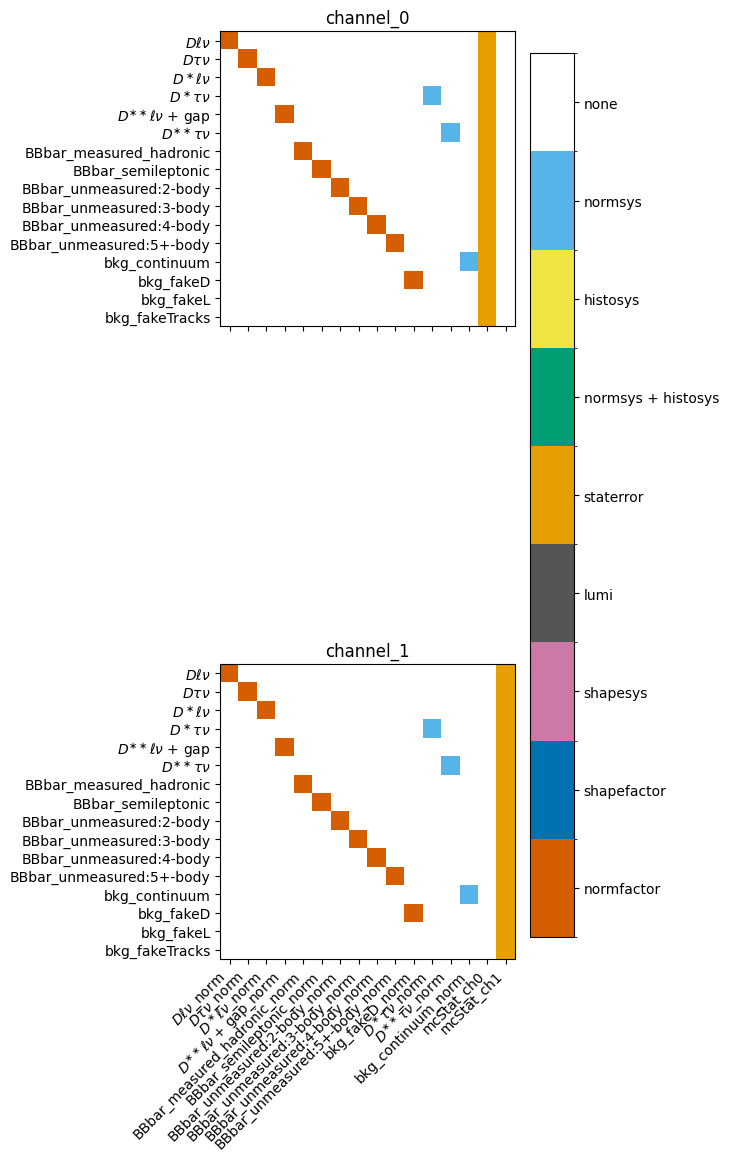

In [11]:
model_comb_e, data_comb_e = cabinetry.model_utils.model_and_data(spec_comb_e)
pars = model_comb_e.config.suggested_init()

norm_parameter_names = [par for par in model_comb_e.config.par_order if par.endswith('_norm')]
for par in norm_parameter_names:
    model_comb_e.config.param_set(par).suggested_bounds=[[0,5]]
    # if par=='SemileptonicB2D_PrimaryLepton_norm':
    #     model_comb.config.param_set(par).suggested_bounds=[[-0.9,1.1]]
    if par.startswith('$'):
        model_comb_e.config.param_set(par).suggested_fixed=[True]

model_comb_e.config.param_set(r'$D^{\ast\ast}\ell\nu$ + gap_norm').suggested_init=[1]
model_comb_e.config.param_set('bkg_continuum_norm').suggested_fixed=[False]
model_comb_e.config.param_set('BBbar_semileptonic_norm').suggested_fixed=[True]
model_comb_e.config.param_set('BBbar_measured_hadronic_norm').suggested_fixed=[False]
model_comb_e.config.param_set('BBbar_unmeasured:2-body_norm').suggested_init=[1]
model_comb_e.config.param_set('BBbar_unmeasured:2-body_norm').suggested_fixed=[False]
model_comb_e.config.param_set('BBbar_unmeasured:3-body_norm').suggested_init=[1]
model_comb_e.config.param_set('BBbar_unmeasured:3-body_norm').suggested_fixed=[False]
model_comb_e.config.param_set('BBbar_unmeasured:4-body_norm').suggested_init=[0.68]
# model_comb_e.config.param_set('BBbar_unmeasured:5-body_norm').suggested_init=[0.1]
# model_comb_e.config.param_set('BBbar_unmeasured:6-body_norm').suggested_init=[0.1]
# model_comb_e.config.param_set('BBbar_unmeasured:7-body_norm').suggested_init=[0.1]
model_comb_e.config.param_set('BBbar_unmeasured:5+-body_norm').suggested_init=[0.1]

cabinetry.visualize.modifier_grid(model_comb_e)
# cabinetry.visualize.modifier_grid(pyhf.Workspace(spec_comb_e).model())

In [12]:
%%time
# e mode, staterror
fit_results = cabinetry.fit.fit(model=model_comb_e, data=data_comb_e,goodness_of_fit=True,
#                                 init_pars=[1]*7+[10]*3+pars[10:],
                                # fix_pars=[True]*4
                               )

INFO - cabinetry.fit - performing maximum likelihood fit
INFO - cabinetry.fit - Migrad status:
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2086                       │            Nfcn = 276790             │
│ EDM = 4.01e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴─────────────────────────────────

CPU times: user 2min 45s, sys: 245 ms, total: 2min 45s
Wall time: 2min 46s
